In [434]:
import importlib
import sys
sys.path.append("/home/nichettg/Linux Programmi/Codici")

import numpy as np
import funzioni as f
importlib.reload(f)

import matplotlib.pyplot as plt
import grafici as gf
importlib.reload(gf)

<module 'grafici' from '/home/nichettg/Linux Programmi/Codici/grafici.py'>

# 1. Raccolta dati

Funzione conversione unità di misura

In [435]:
def converti(P_kgcm2, V_cm3, T_C):
    
    # 1 kg/cm² = 98_066.5 Pa
    P_Pa = 98066.5 * P_kgcm2
    # 1 cm³ = 1e6 m³
    V_m3 = 1e-6 * V_cm3
    # °C to K
    T_K = T_C + 273.15

    return P_Pa, V_m3, T_K

Inizio e fine dello "zoom"

In [436]:
v_min = 9
v_max = 20

Lettura dati cartella Data

In [437]:
import os

input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir('./Data'))]
dati,dati_completi = {}, {}

for i, input_file in enumerate(input_files):
    array = np.loadtxt(input_file)
    P, V, T = array[:, 0], array[:, 1], array[:, 2]

    dati_completi[f"{(i+1)*10+5}"] = {"P": P.copy(), "V": V.copy(), "T": T.copy()}

    index = np.argmin(V)

    comp = {"P": P[:index], "V": V[:index], "T": T[:index]}
    exp  = {"P": P[index:], "V": V[index:], "T": T[index:]}

    dati[f"{(i+1)*10+5}"] = {
        "compressione": {chiave: variabile[ (comp['V'] > v_min) & (comp['V'] < v_max) ] for chiave,variabile in comp.items()}, 
        "espansione": {chiave: variabile[ (comp['V'] > v_min) & (comp['V'] < v_max) ] for chiave,variabile in comp.items()}
    }

Tabella di controllo

In [438]:
import pandas as pd
df = pd.DataFrame(dati)
print(df)

                                                             15  \
compressione  {'P': [1.282, 1.283, 1.285, 1.285, 1.286, 1.28...   
espansione    {'P': [1.282, 1.283, 1.285, 1.285, 1.286, 1.28...   

                                                             25  \
compressione  {'P': [1.316, 1.316, 1.316, 1.317, 1.317, 1.31...   
espansione    {'P': [1.316, 1.316, 1.316, 1.317, 1.317, 1.31...   

                                                             35  \
compressione  {'P': [1.362, 1.363, 1.363, 1.364, 1.365, 1.36...   
espansione    {'P': [1.362, 1.363, 1.363, 1.364, 1.365, 1.36...   

                                                             45  \
compressione  {'P': [1.407, 1.407, 1.408, 1.409, 1.409, 1.40...   
espansione    {'P': [1.407, 1.407, 1.408, 1.409, 1.409, 1.40...   

                                                             55  
compressione  {'P': [1.446, 1.446, 1.446, 1.446, 1.447, 1.44...  
espansione    {'P': [1.446, 1.446, 1.446, 1.446, 1.447, 1.44

# 2. Fit lineare volume e grafici

Regressione lineare (Minimi quadrati III opzionali)

In [439]:
# Least Squares III
ls3 = True

In [440]:
sx = 0.01 / np.sqrt(12)
#sy = 0.001 / np.sqrt(12)
sy = 0.3

In [441]:
parametri = {}

for i, (temp, serie) in enumerate(dati.items()):
    parametri[temp] = {}
    for fase_chiave, fase in serie.items():
        output_filename = input_files[i].replace( "Data", "Elaborati").replace( "GR03_", "").replace( ".txt", f"_{fase_chiave}.txt") 
        if ls3 == True:
            a,b,sa,sb,cov,p = f.elaborato(1/fase["P"], fase["V"], sy, output_filename, int(temp)-1 , sx/(fase["P"]**2), ritorno = True)
        else:
            a,b,sa,sb,cov,p = f.elaborato(1/fase["P"], fase["V"], sy, output_filename, int(temp)-1, ritorno = True)
        parametri[temp][fase_chiave] = {
            "a": a, "b": b, "sa": sa, "sb": sb, "cov": cov, "p": p
        }


Elaborazione serie 15
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 15
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 25
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 25
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 35
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 35
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 45
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 45
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 55
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 55
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3


Tabella di controllo

In [442]:
df = pd.DataFrame(parametri)
print(df)

                                                             15  \
compressione  {'a': -1.2724001503398792, 'b': 27.19823306016...   
espansione    {'a': -1.2724001503398792, 'b': 27.19823306016...   

                                                             25  \
compressione  {'a': -1.9091612419611308, 'b': 28.79580833261...   
espansione    {'a': -1.9091612419611308, 'b': 28.79580833261...   

                                                             35  \
compressione  {'a': -1.2669080649018842, 'b': 28.94758598474...   
espansione    {'a': -1.2669080649018842, 'b': 28.94758598474...   

                                                             45  \
compressione  {'a': -1.2657089168458828, 'b': 29.87538949429...   
espansione    {'a': -1.2657089168458828, 'b': 29.87538949429...   

                                                             55  
compressione  {'a': -3.0188694139527312, 'b': 33.23499075429...  
espansione    {'a': -3.0188694139527312, 'b': 33.23499075429

## 2.1 Grafici

In [443]:
def darken(color, factor=0.6):
    return tuple(factor * c for c in color)

In [444]:
import itertools

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
color_cycle_fisso = itertools.cycle(colors)

cmap = plt.get_cmap('tab10')
color_cycle = itertools.cycle(cmap.colors)

markers = ['o','s','^','D','v']
marker_cycle = itertools.cycle(markers)

errori = gf.default_error_params()
gf.imposta_stile_globale()

### 2.1 Confronto

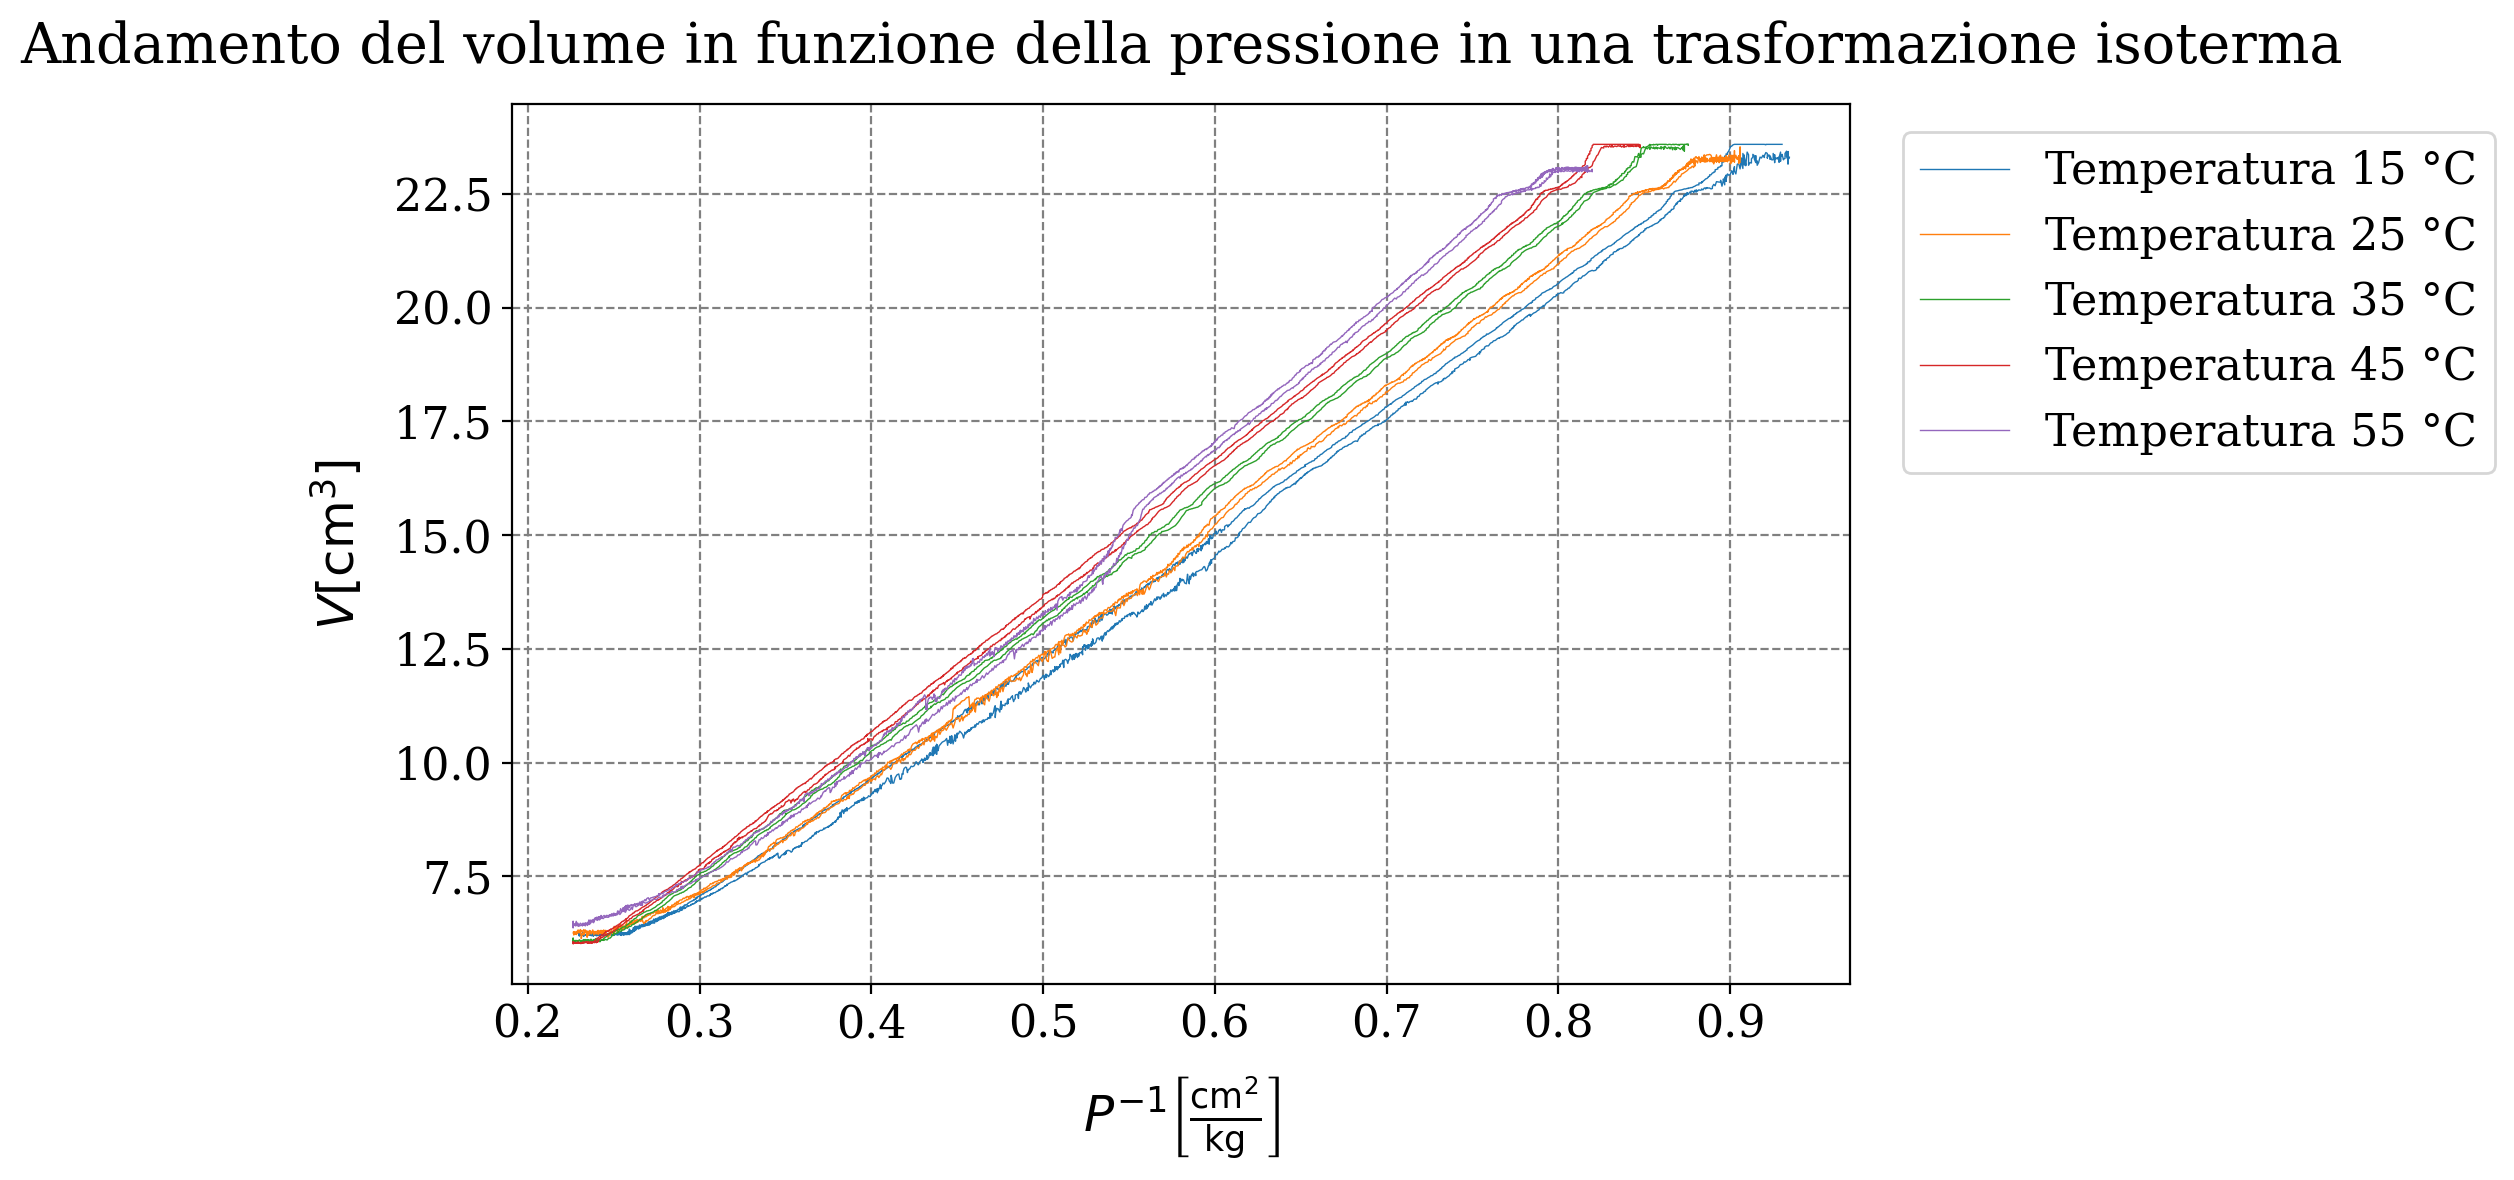

In [445]:
fig, ax = plt.subplots()

for temp, serie in dati_completi.items():
    color = next(color_cycle)
    marker = next(marker_cycle)
    label = f"Temperatura {temp} °C"
    ax.plot(1 / serie["P"], serie["V"], linewidth=0.5, label=label, color=color)

gf.parametri_grafico(ax,
                     titolo = "Andamento del volume in funzione della pressione in una trasformazione isoterma",
                     xlabel = r"$P^{-1} \left[\frac{\mathrm{cm}^2}{\mathrm{kg}}\right]$",
                     ylabel = r"$V [\mathrm{cm^{3}}]$")

gf.salva_grafico(fig, f"./Images/Confronto.pdf", legenda=(1,0.9))

## 2.2 Residui

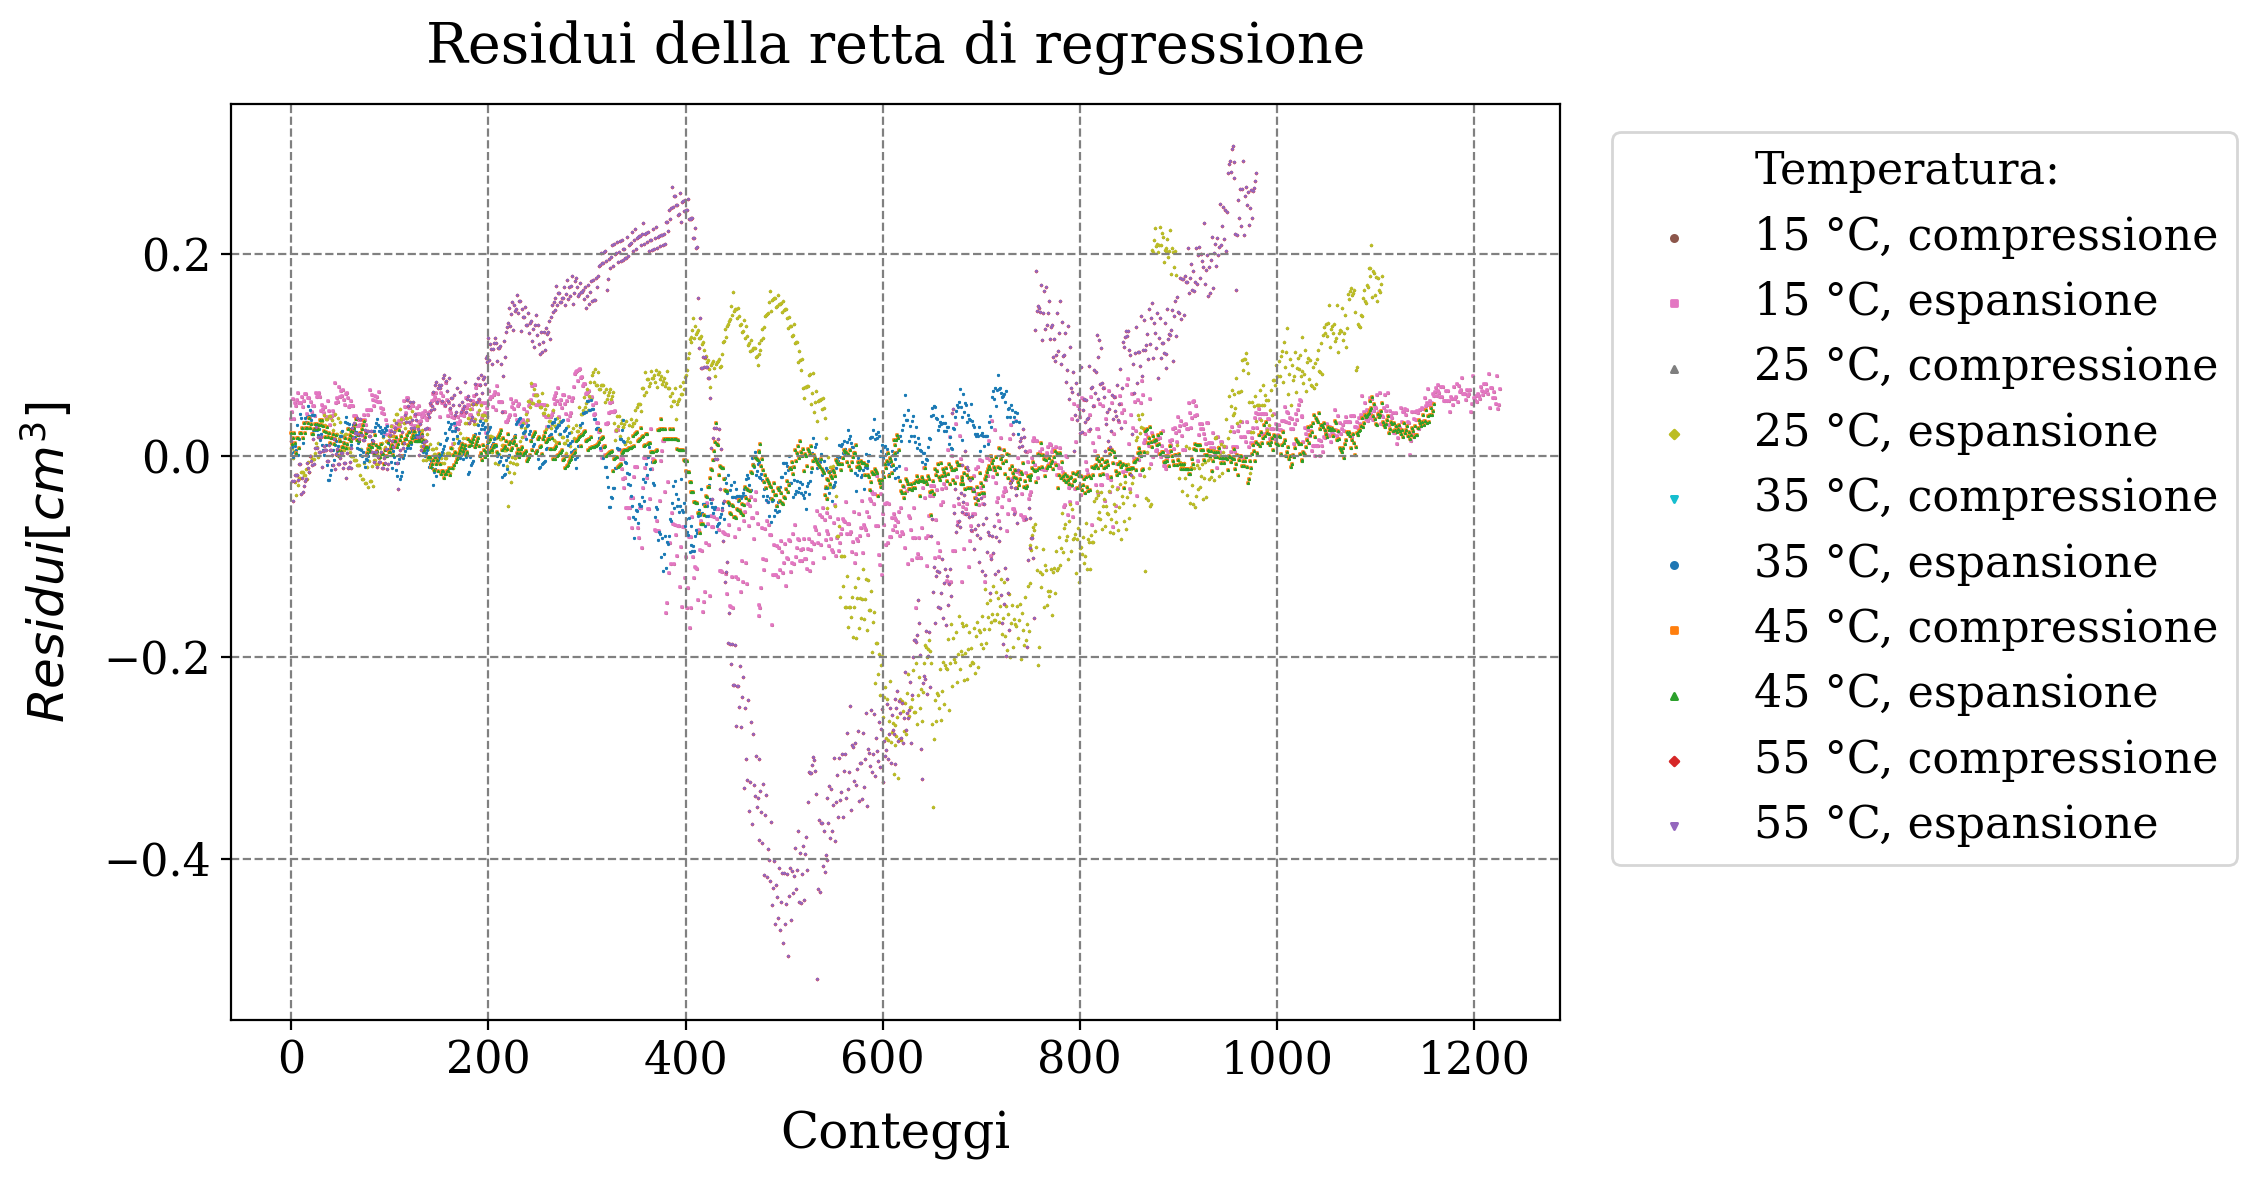

In [446]:
fig, ax = plt.subplots()
gf.descrizione_legenda(ax,"Temperatura:")

for temp,serie in dati.items():
    for fase_chiave, fase in serie.items():
        color = next(color_cycle)
        marker = next(marker_cycle)
        label = f"{temp} °C, {fase_chiave}"

        residui=[]
        a = parametri[temp][fase_chiave]["a"]
        b = parametri[temp][fase_chiave]["b"]

        for y,x in zip(fase["V"],fase["P"]):
            residui.append(y - (a + b * 1/x))
        residui = np.array(residui)
        indici = list(range(0, len(residui)))
        gf.descrizione_legenda(ax, label, color=color, marker=marker)
        ax.scatter(indici, residui, marker=marker, s=0.3, linewidth=0.6, color=color)
        gf.parametri_grafico(ax,
                             titolo = "Residui della retta di regressione",
                             xlabel = "Conteggi",
                             ylabel = r"$Residui [cm^{3}]$")
gf.salva_grafico(fig, f"./Images/Residui.pdf", legenda=(1,0.9))

## 2.3 Serie

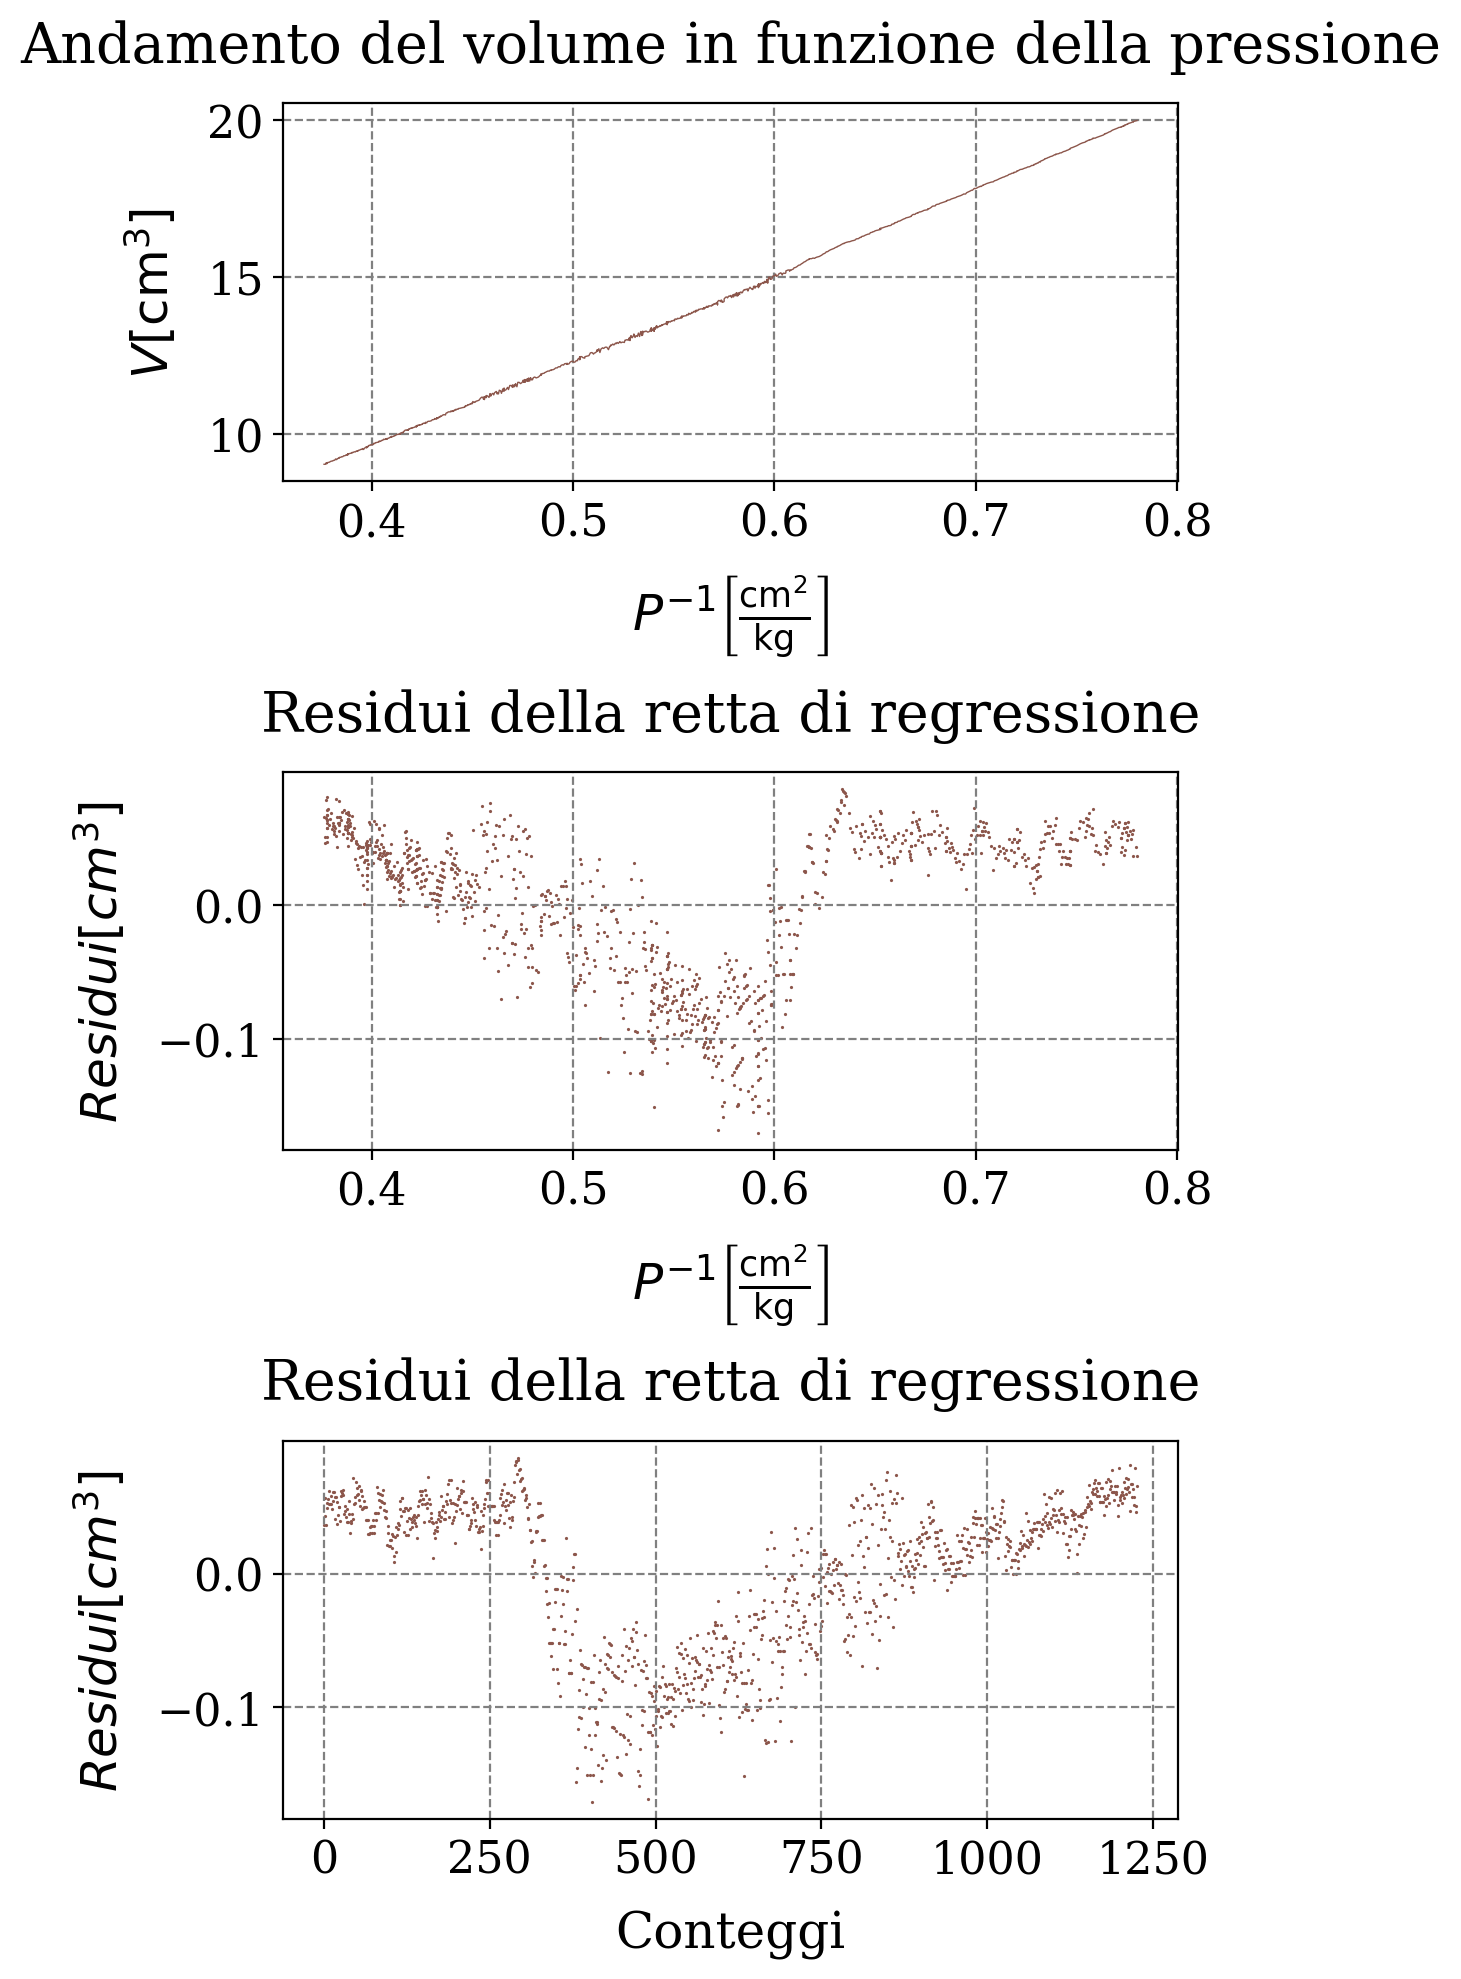

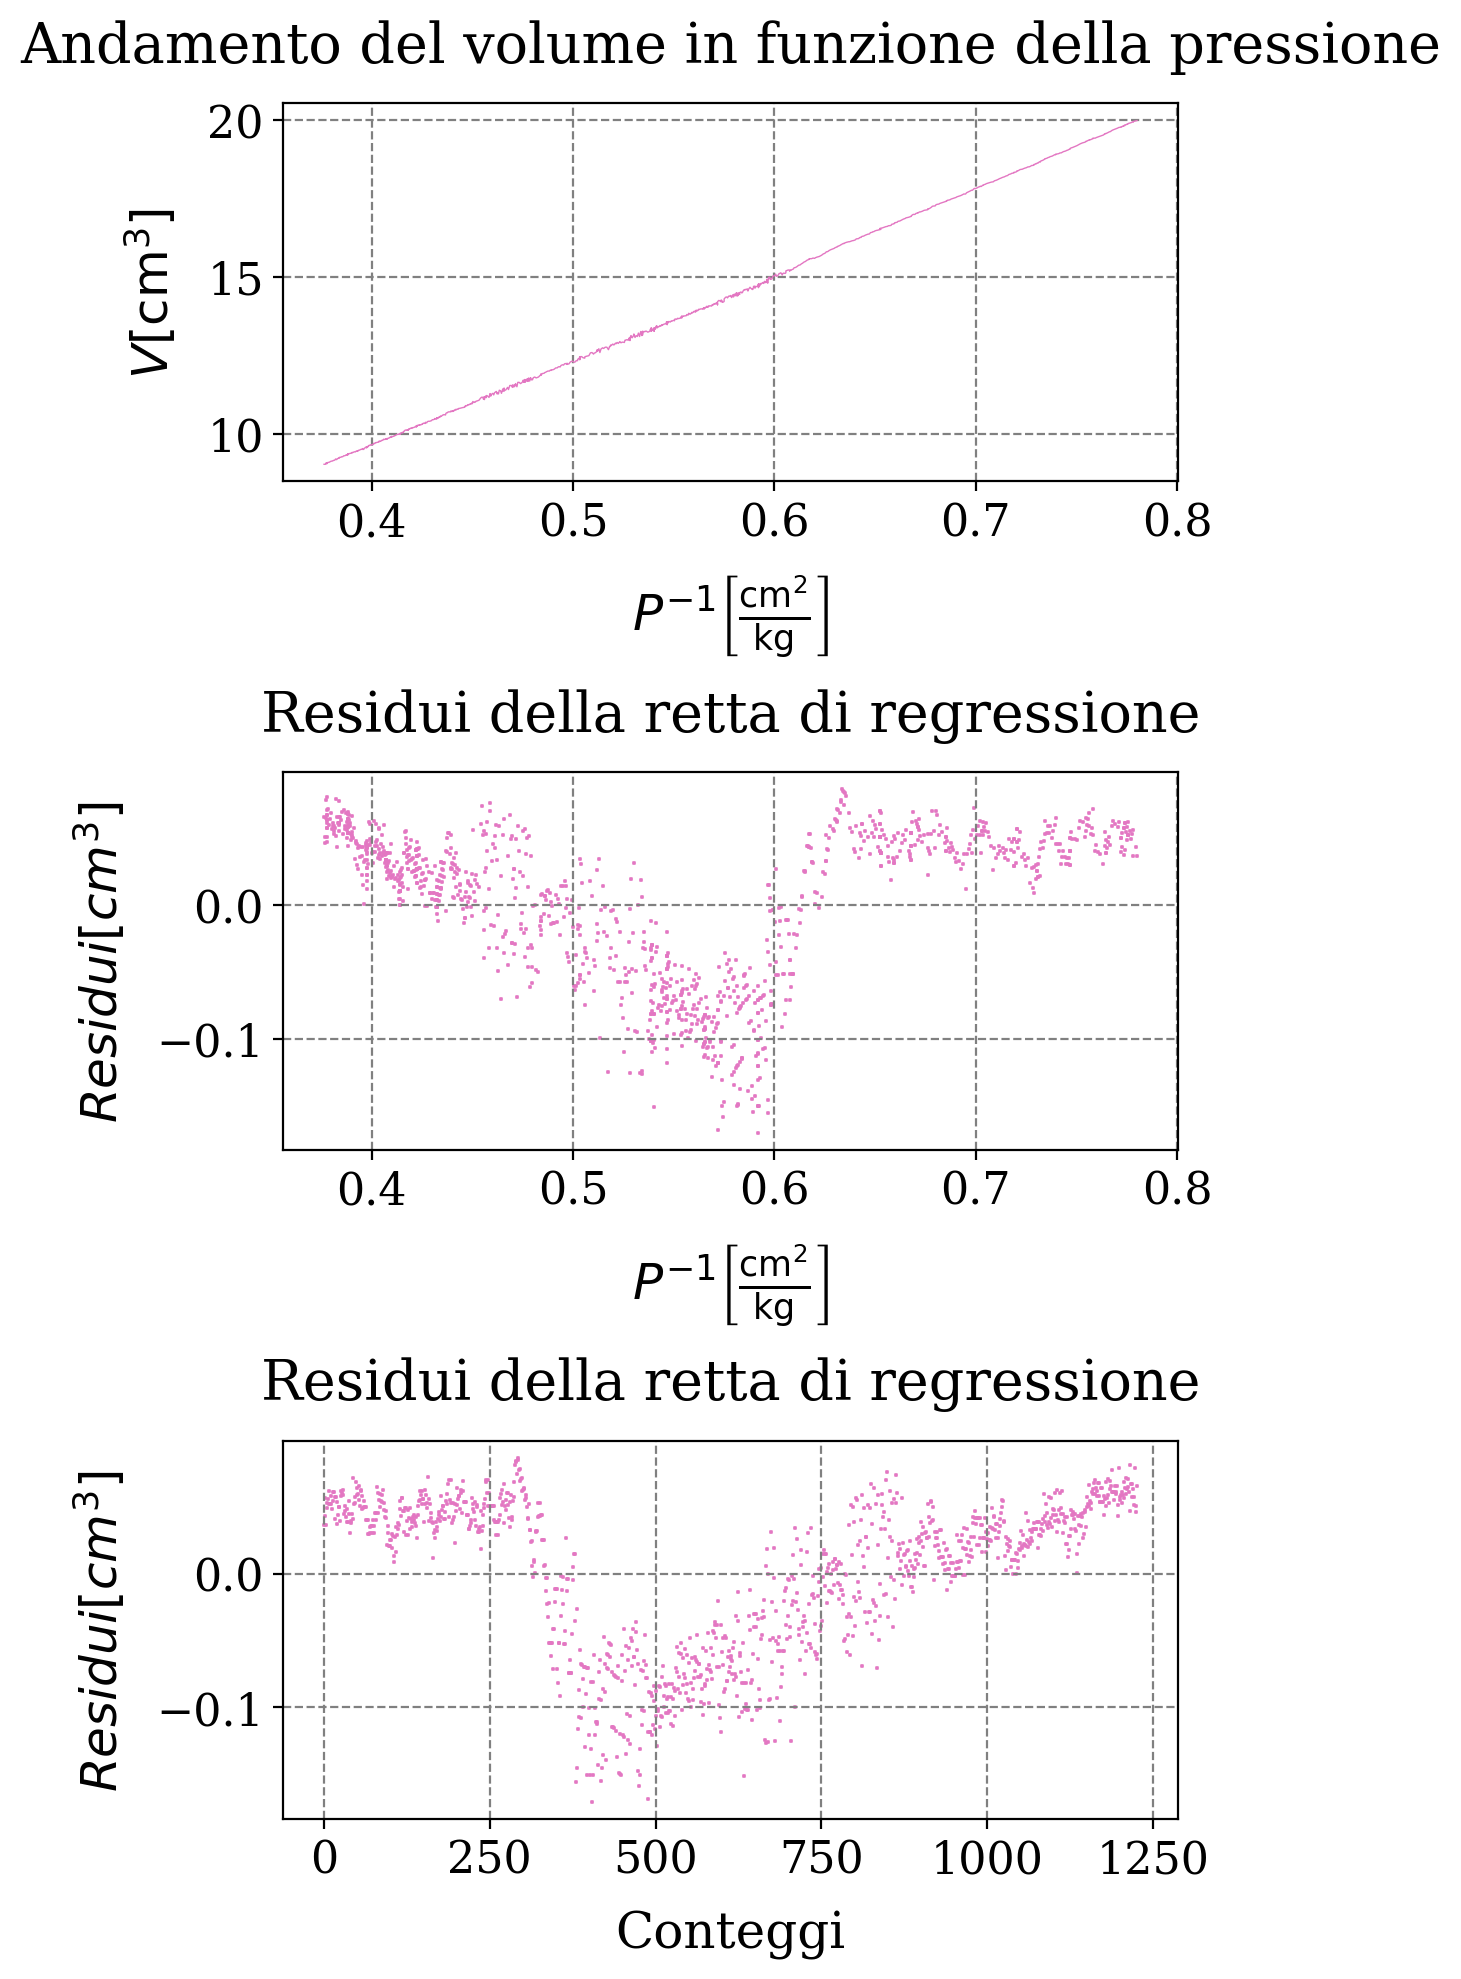

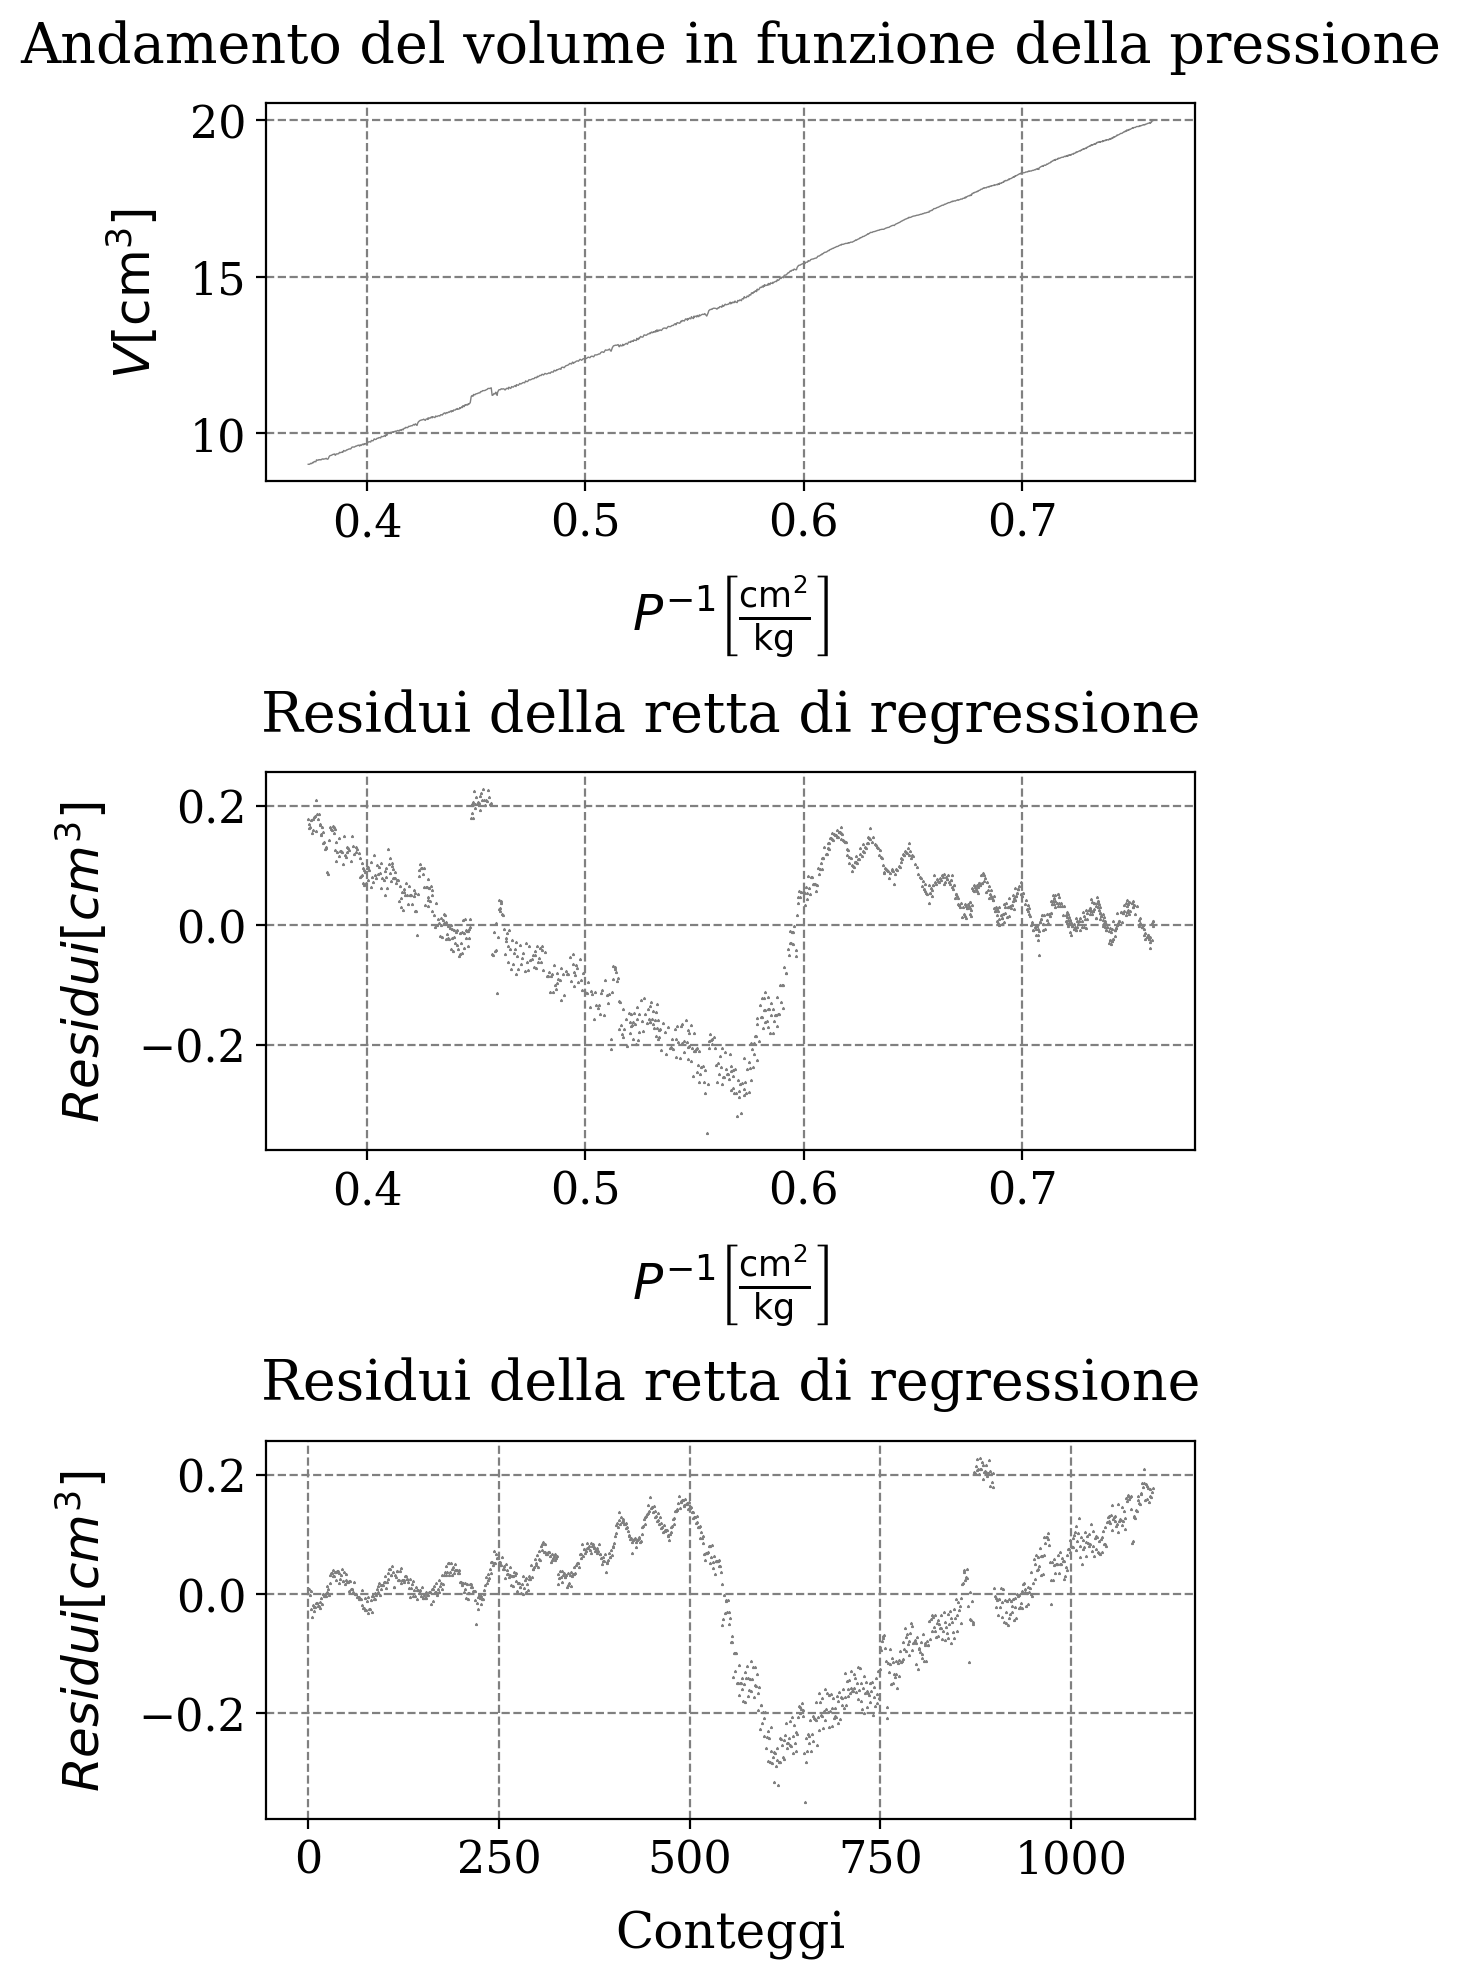

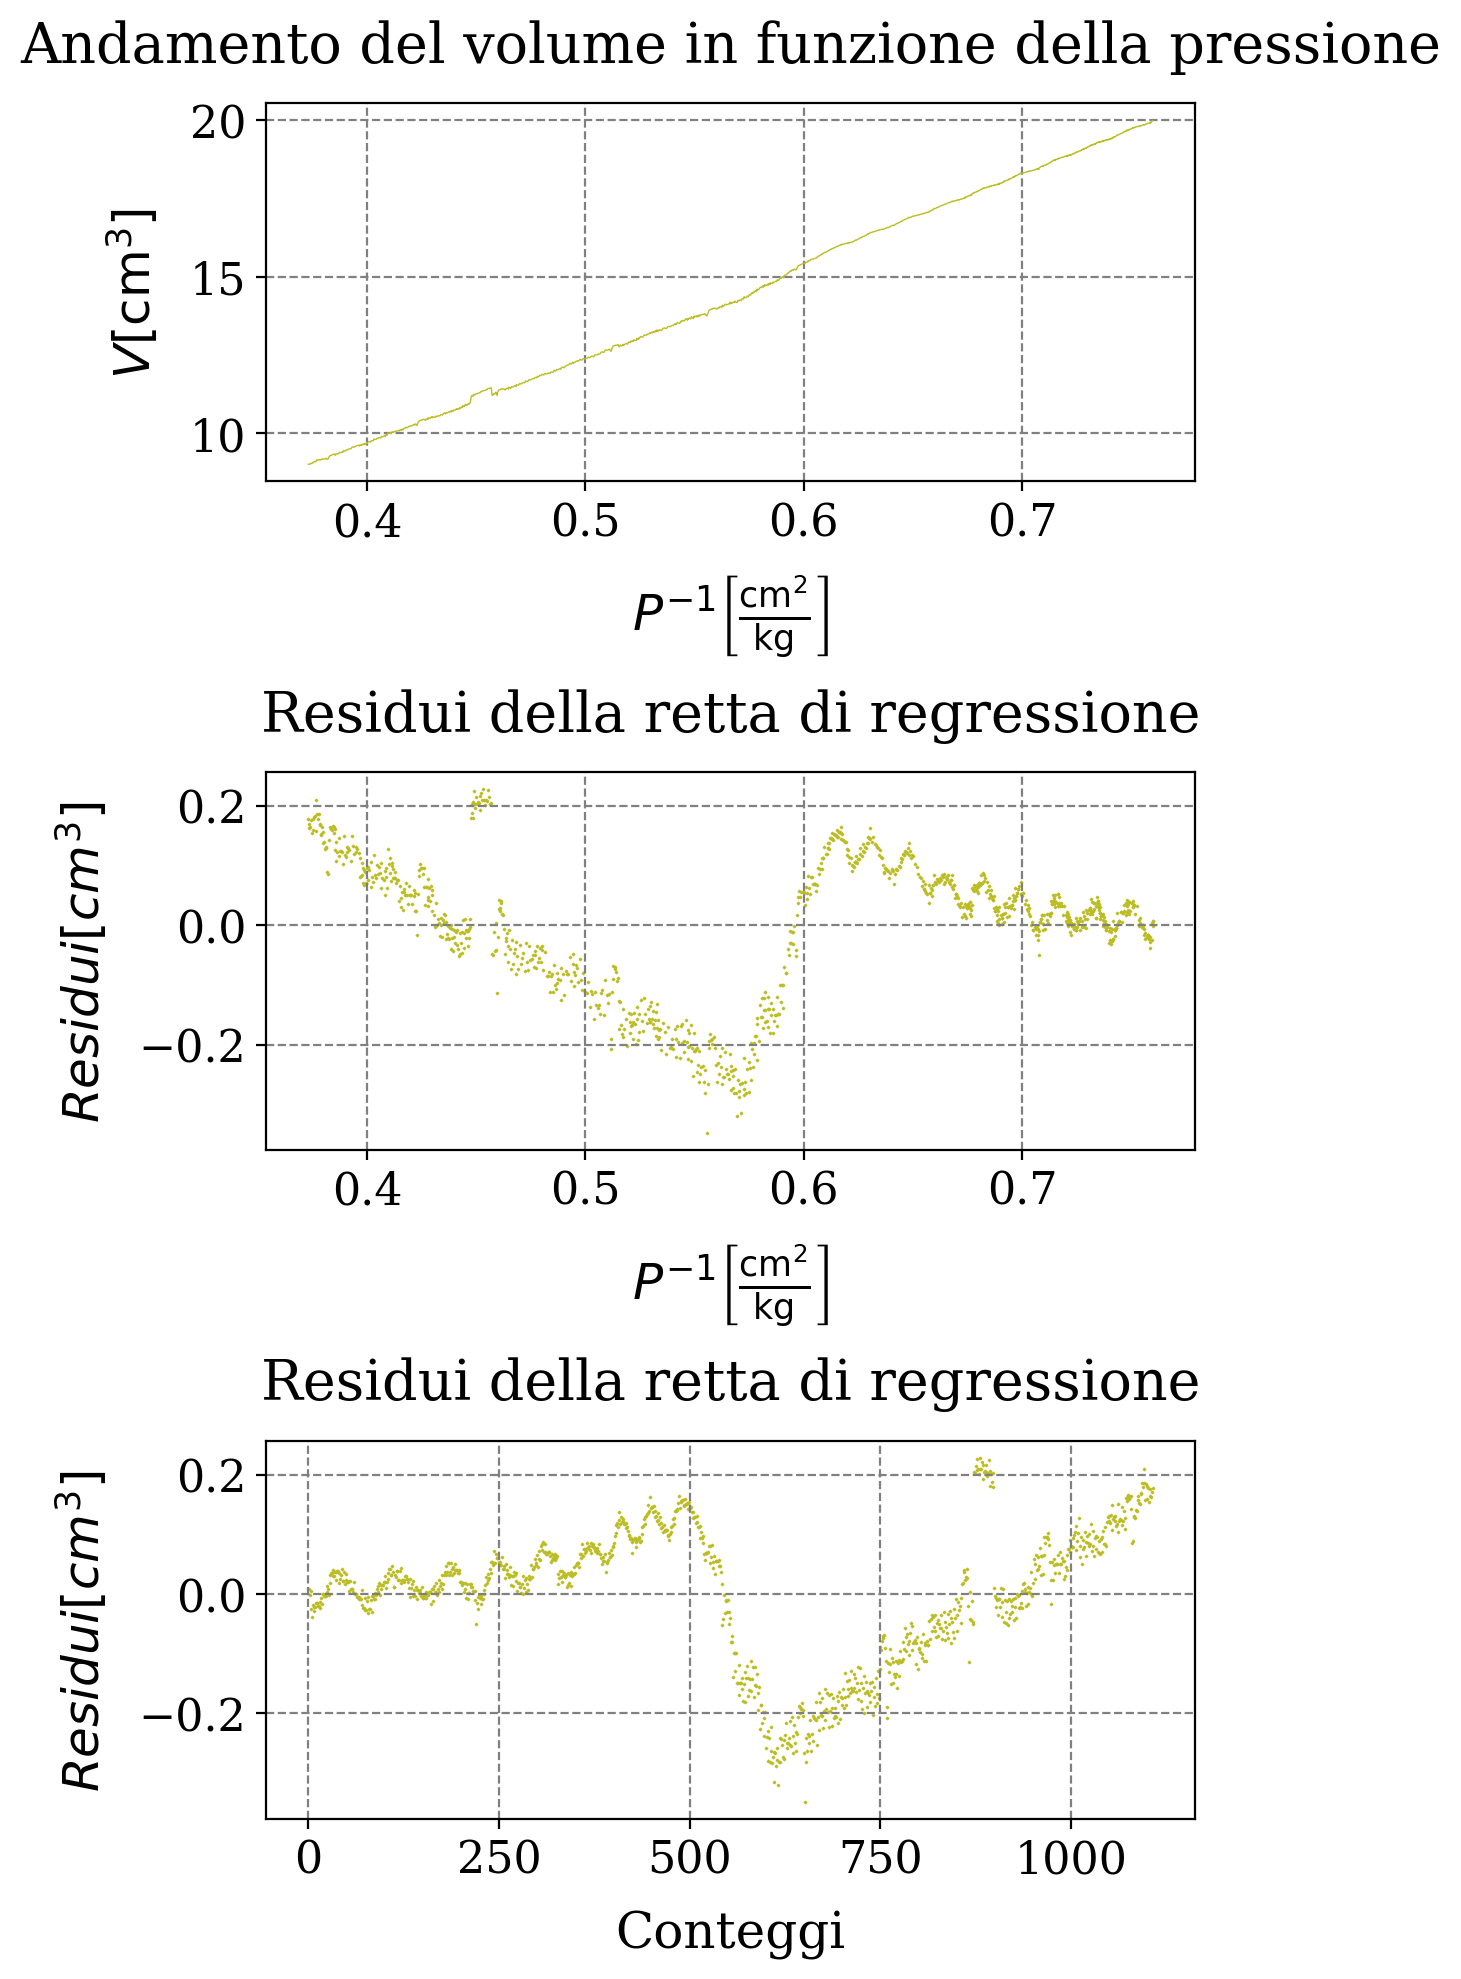

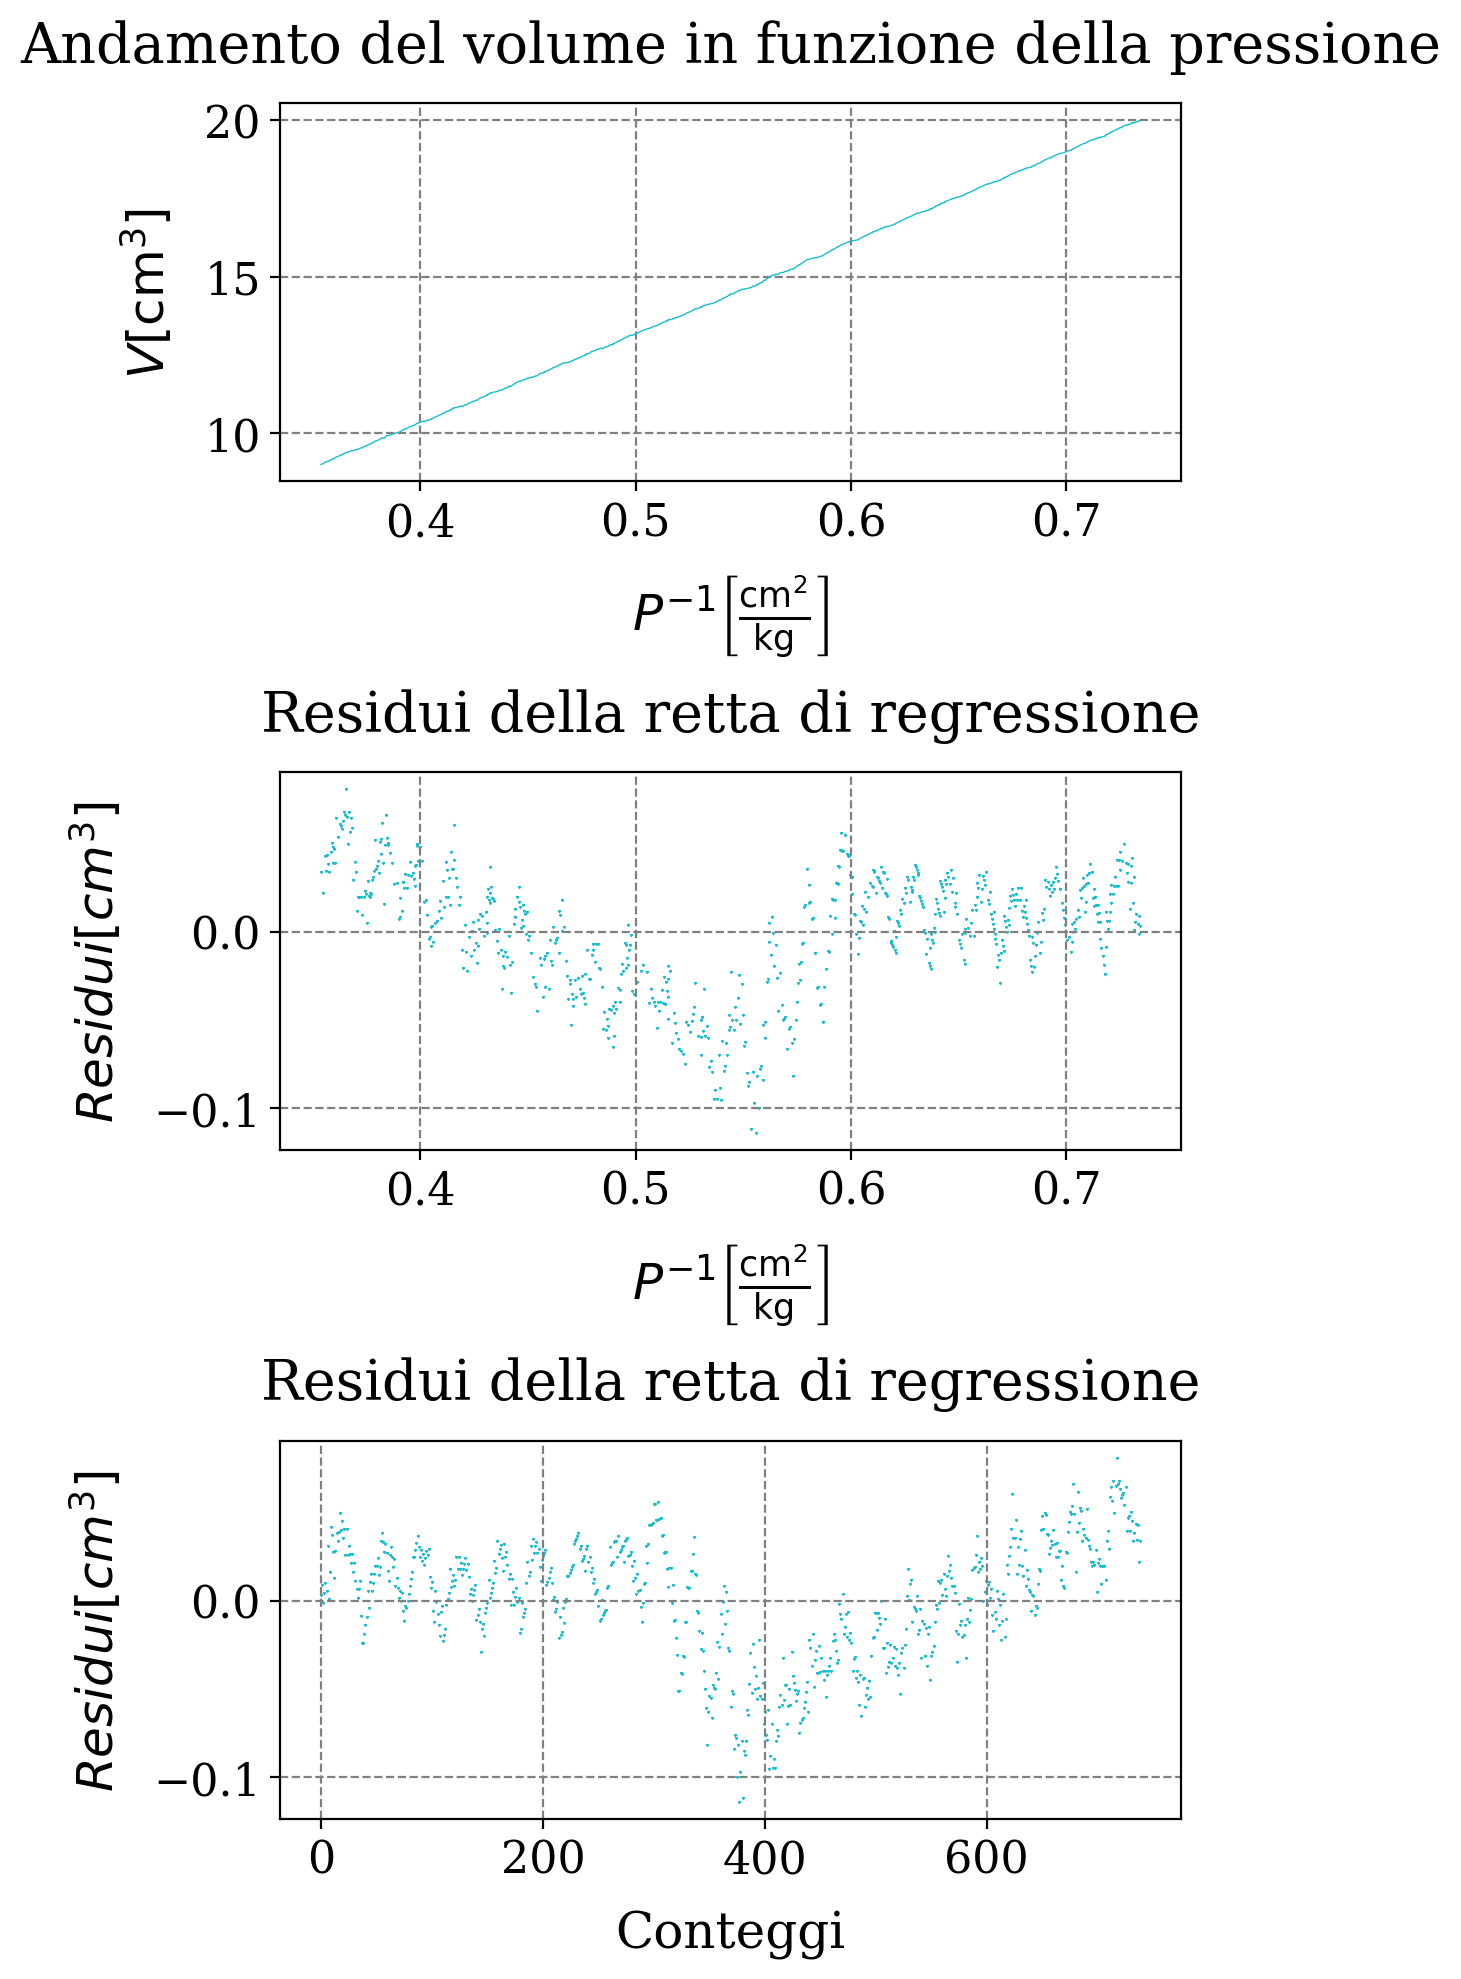

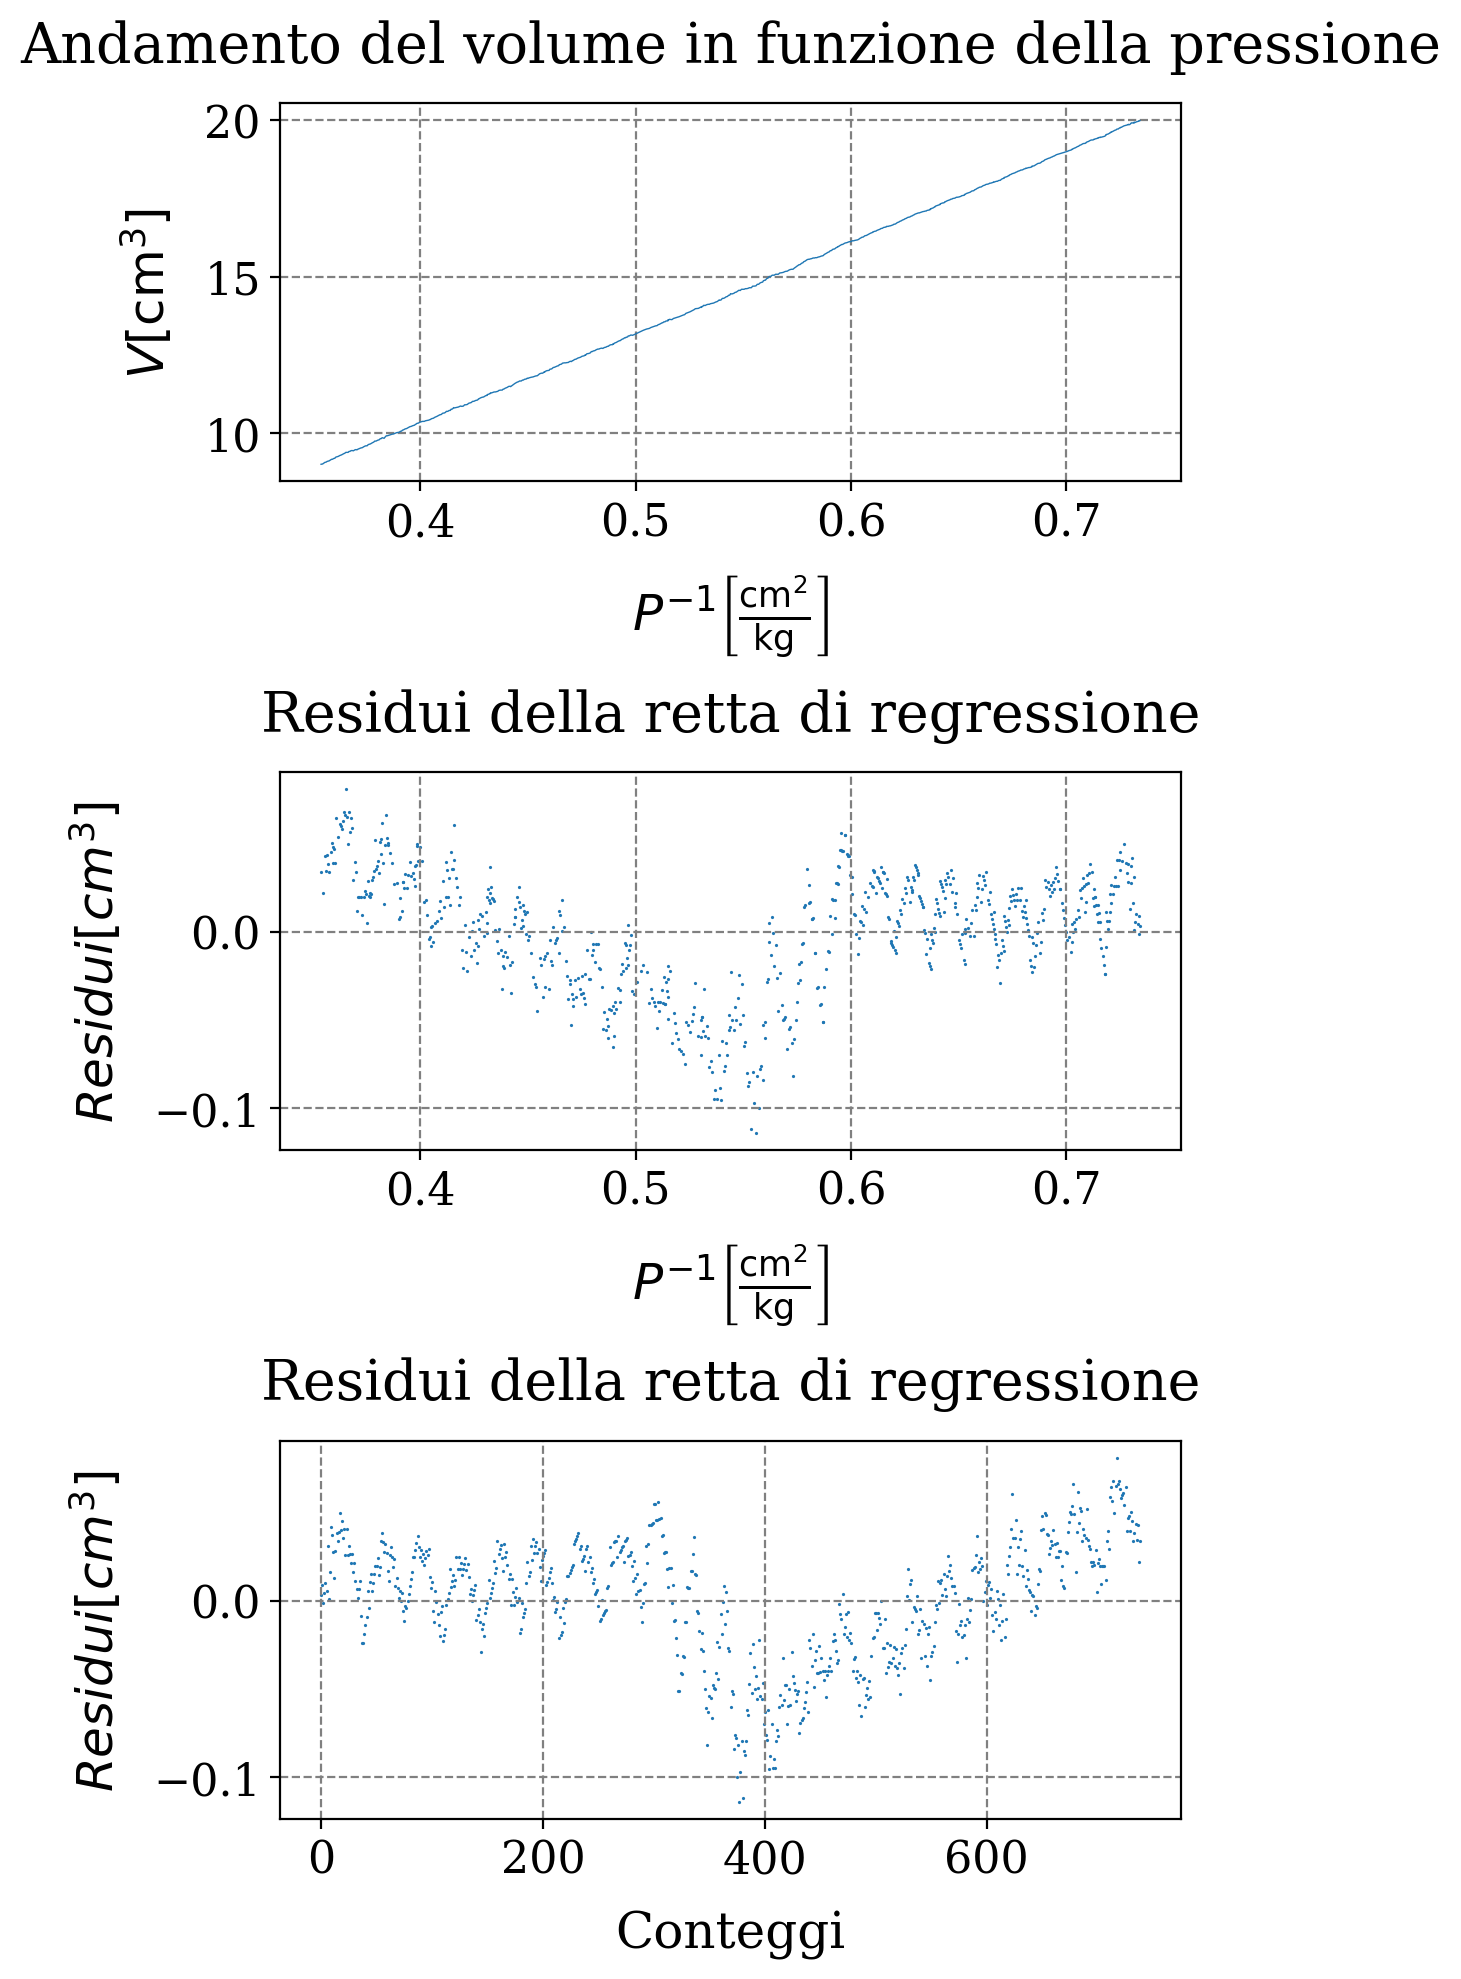

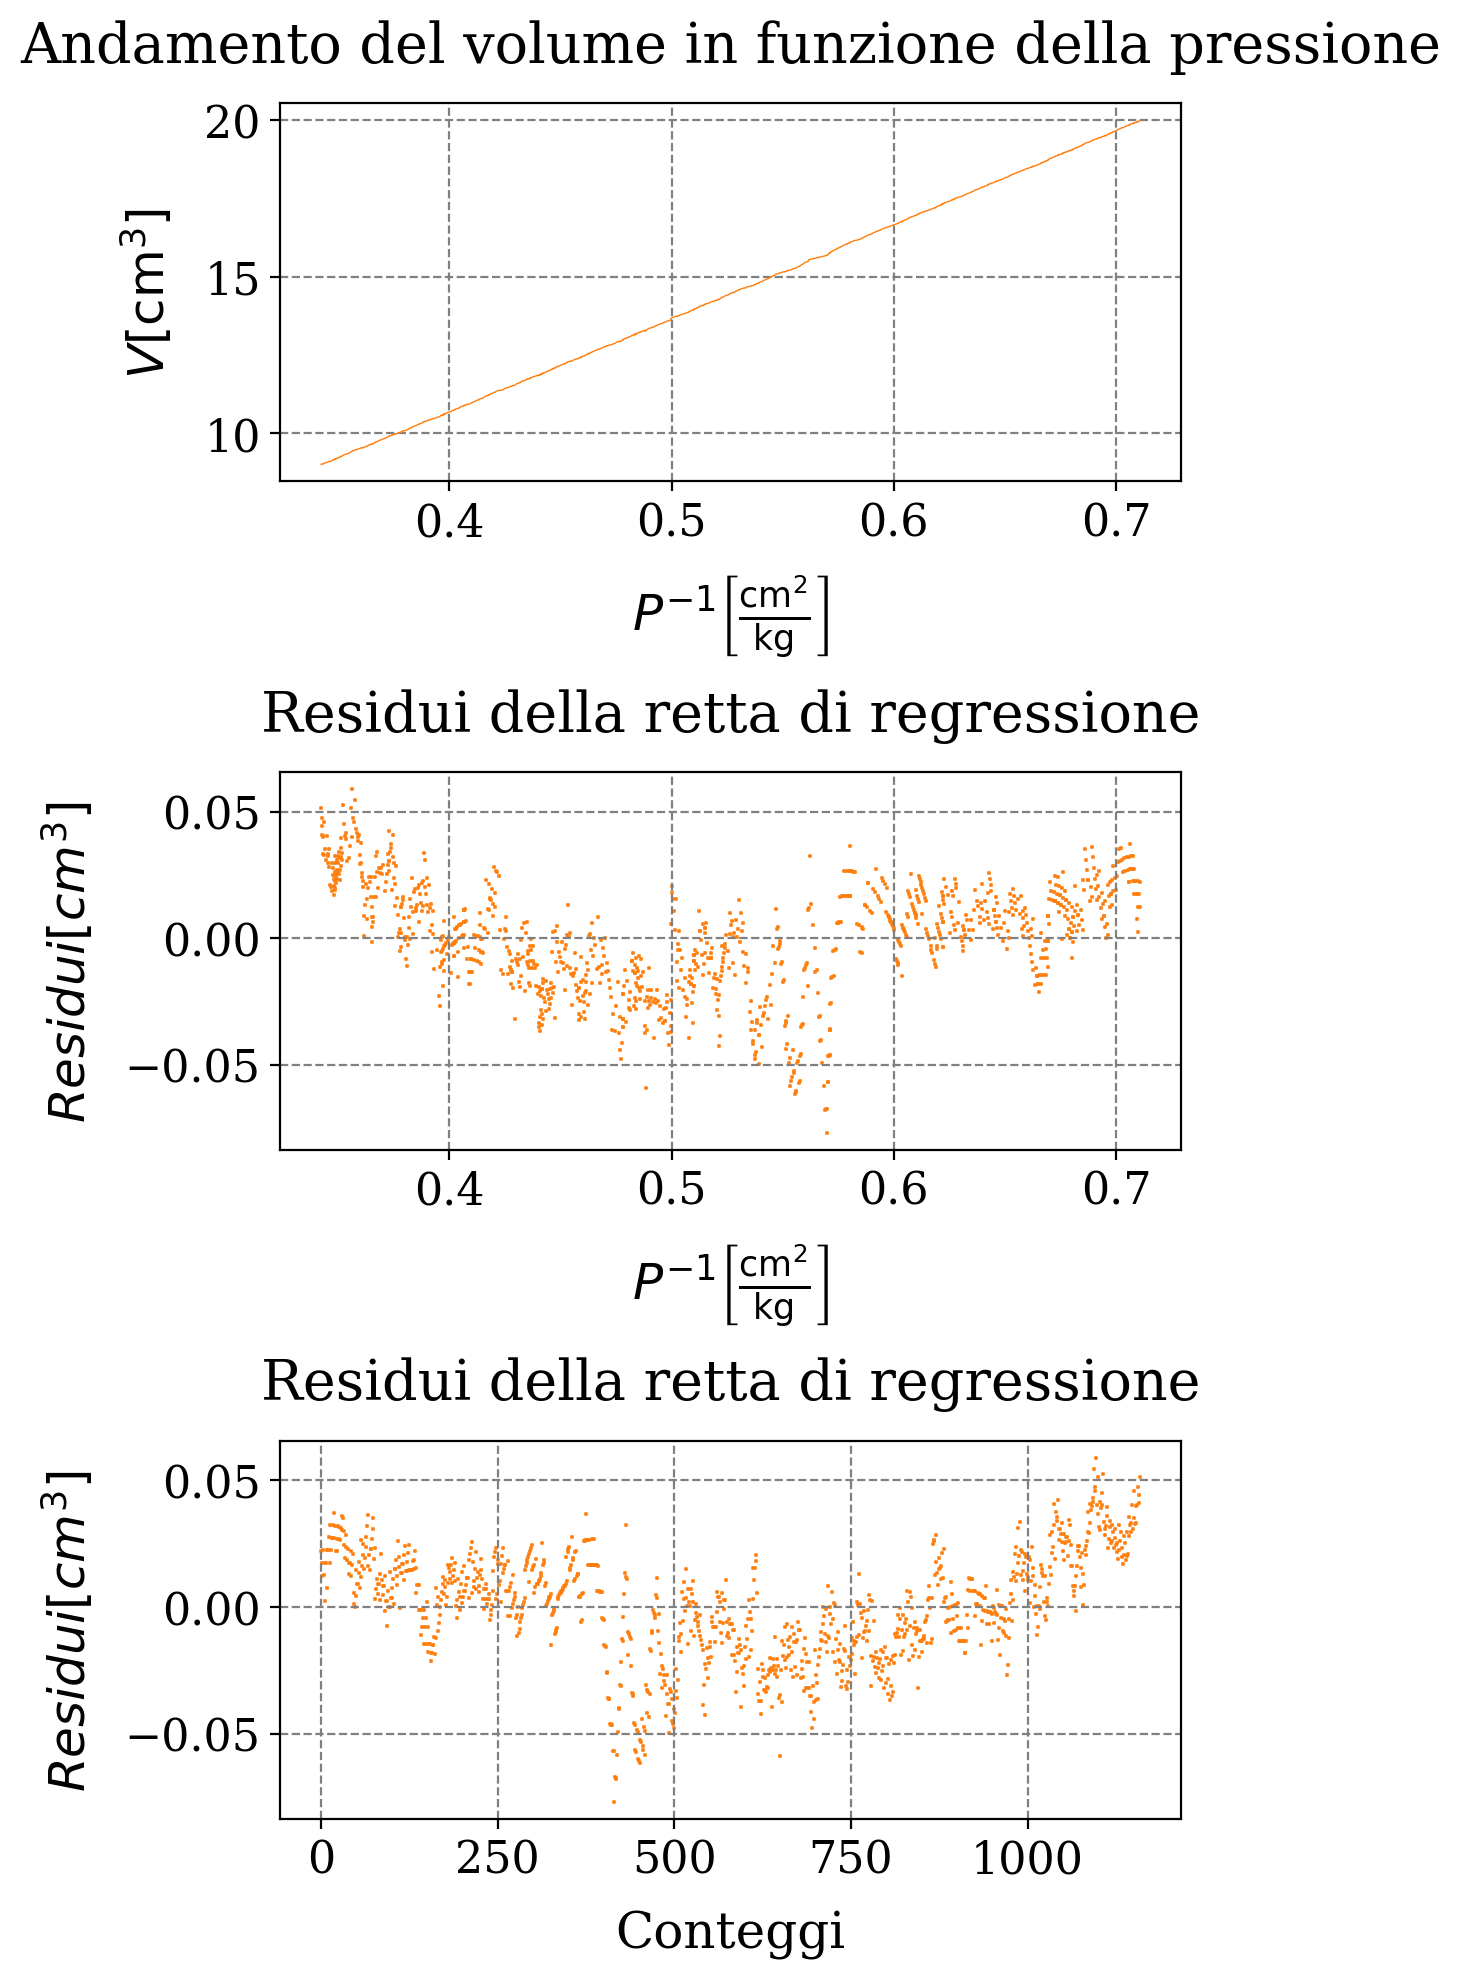

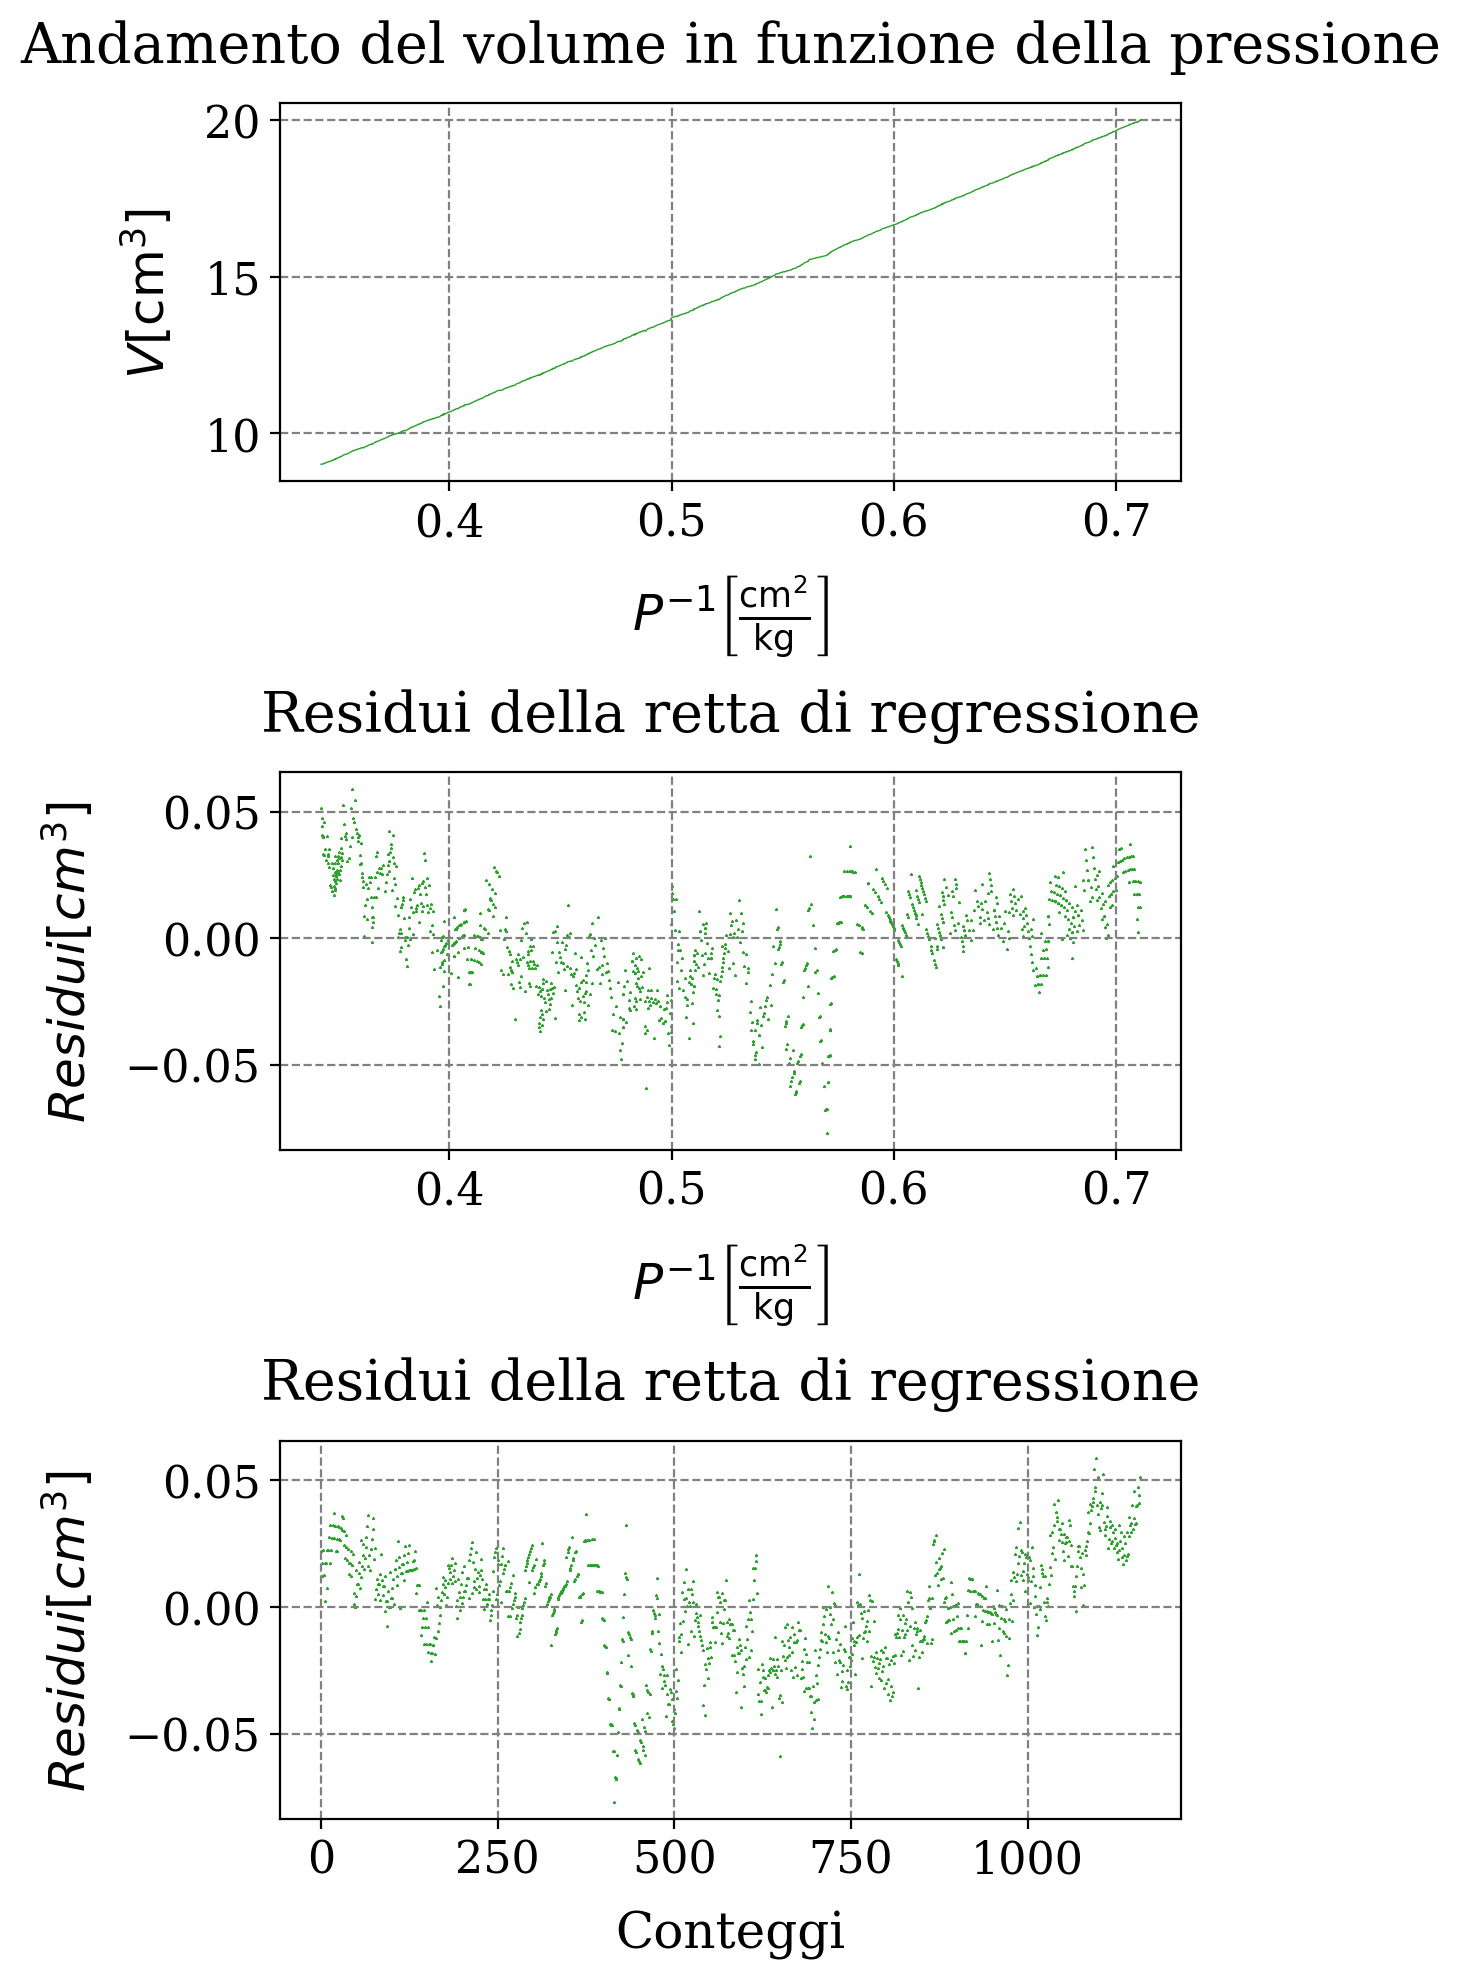

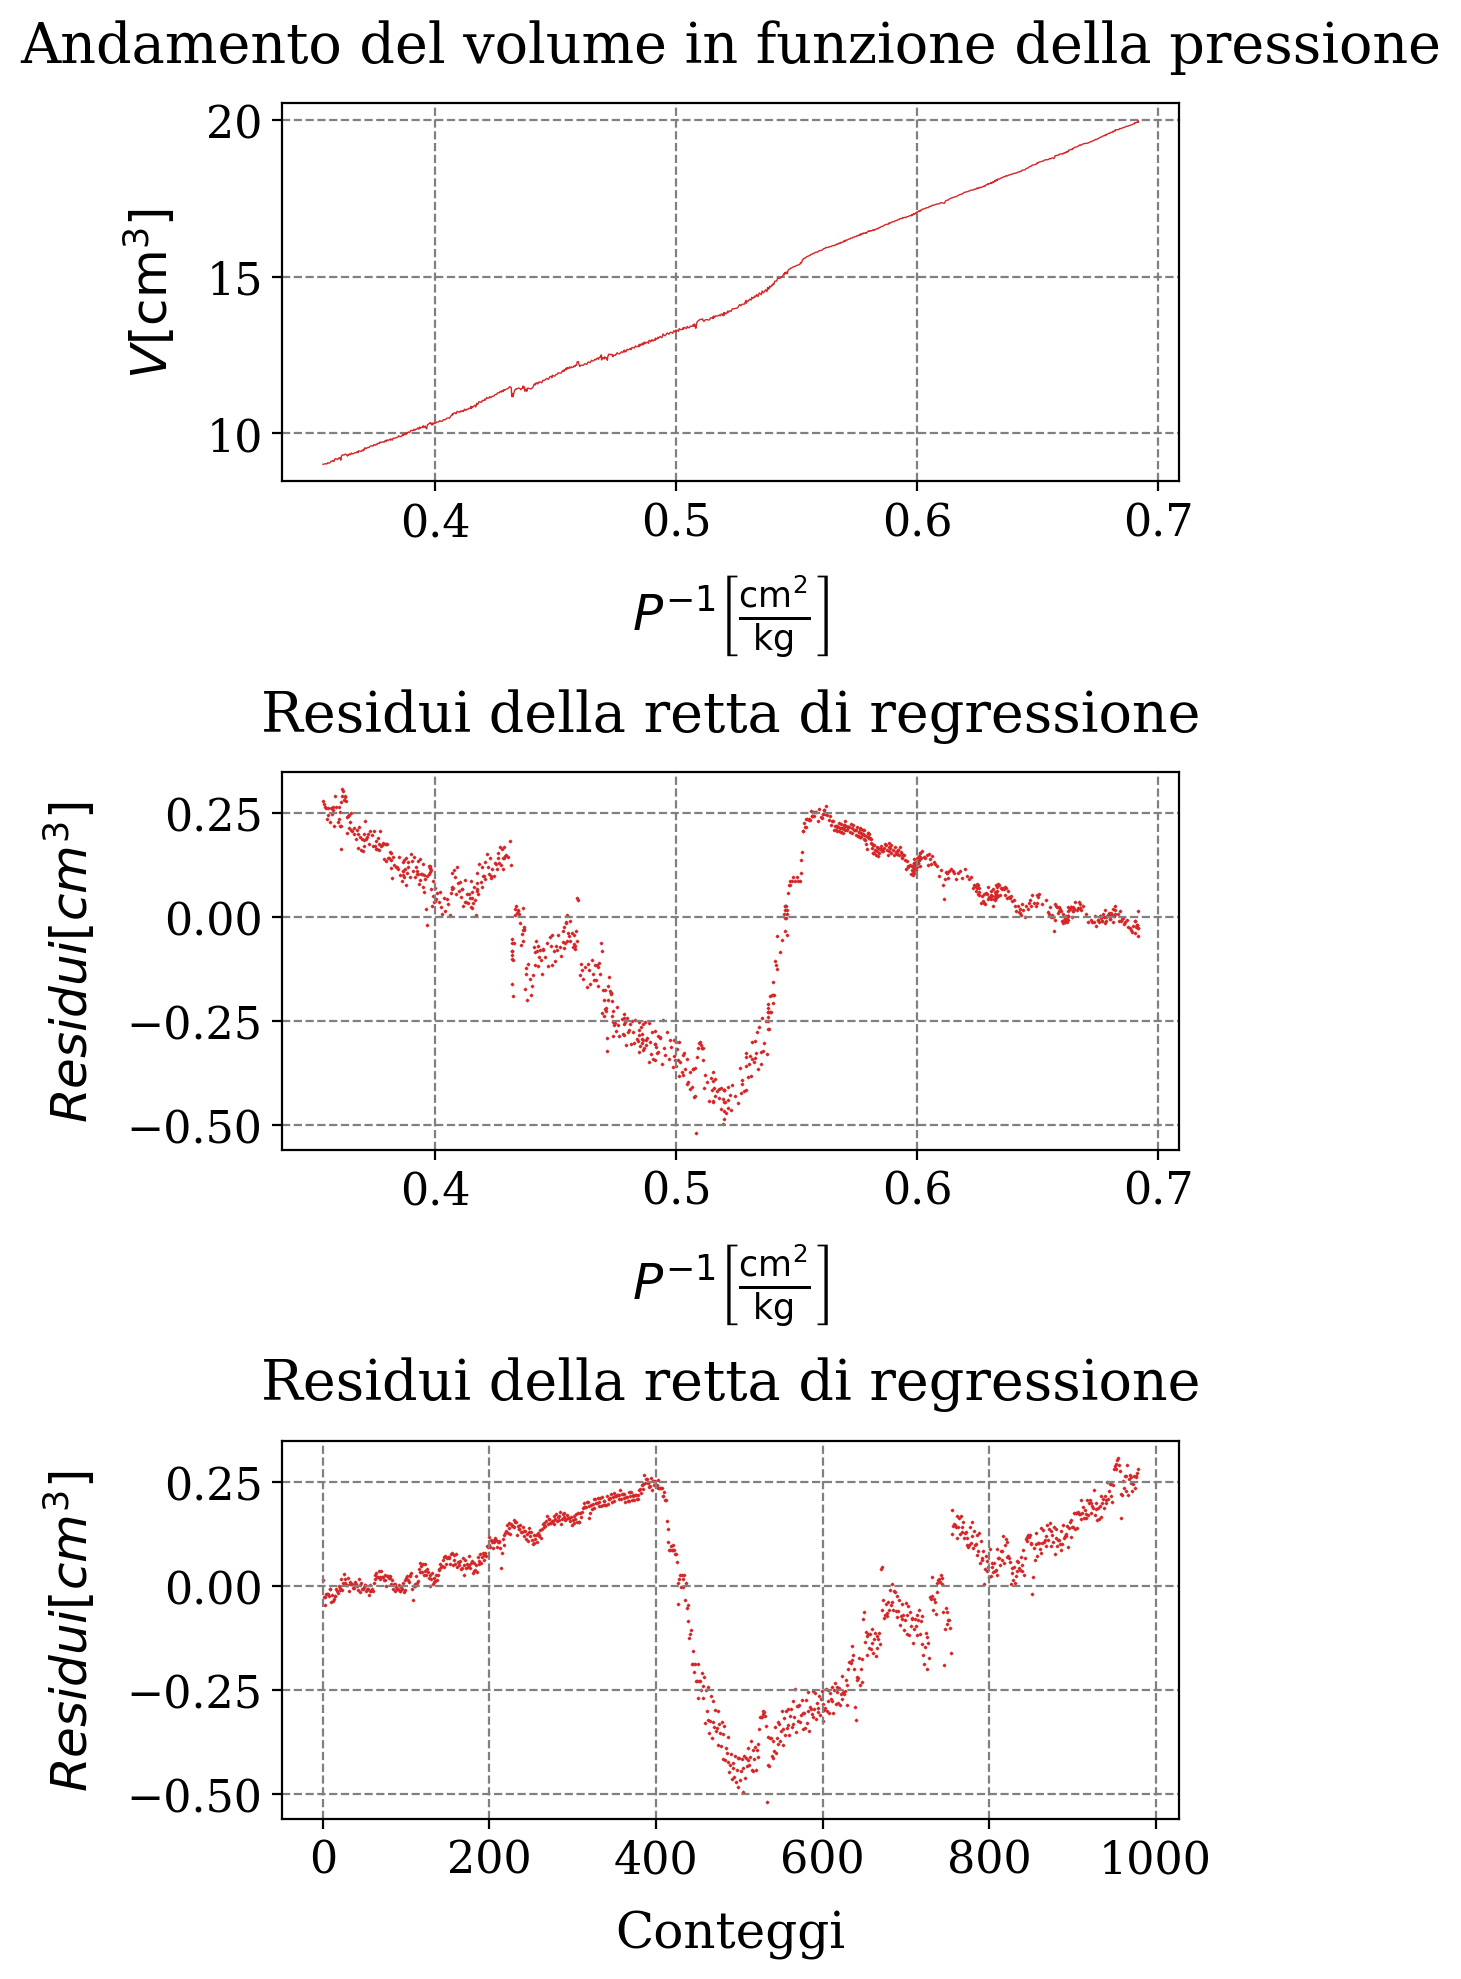

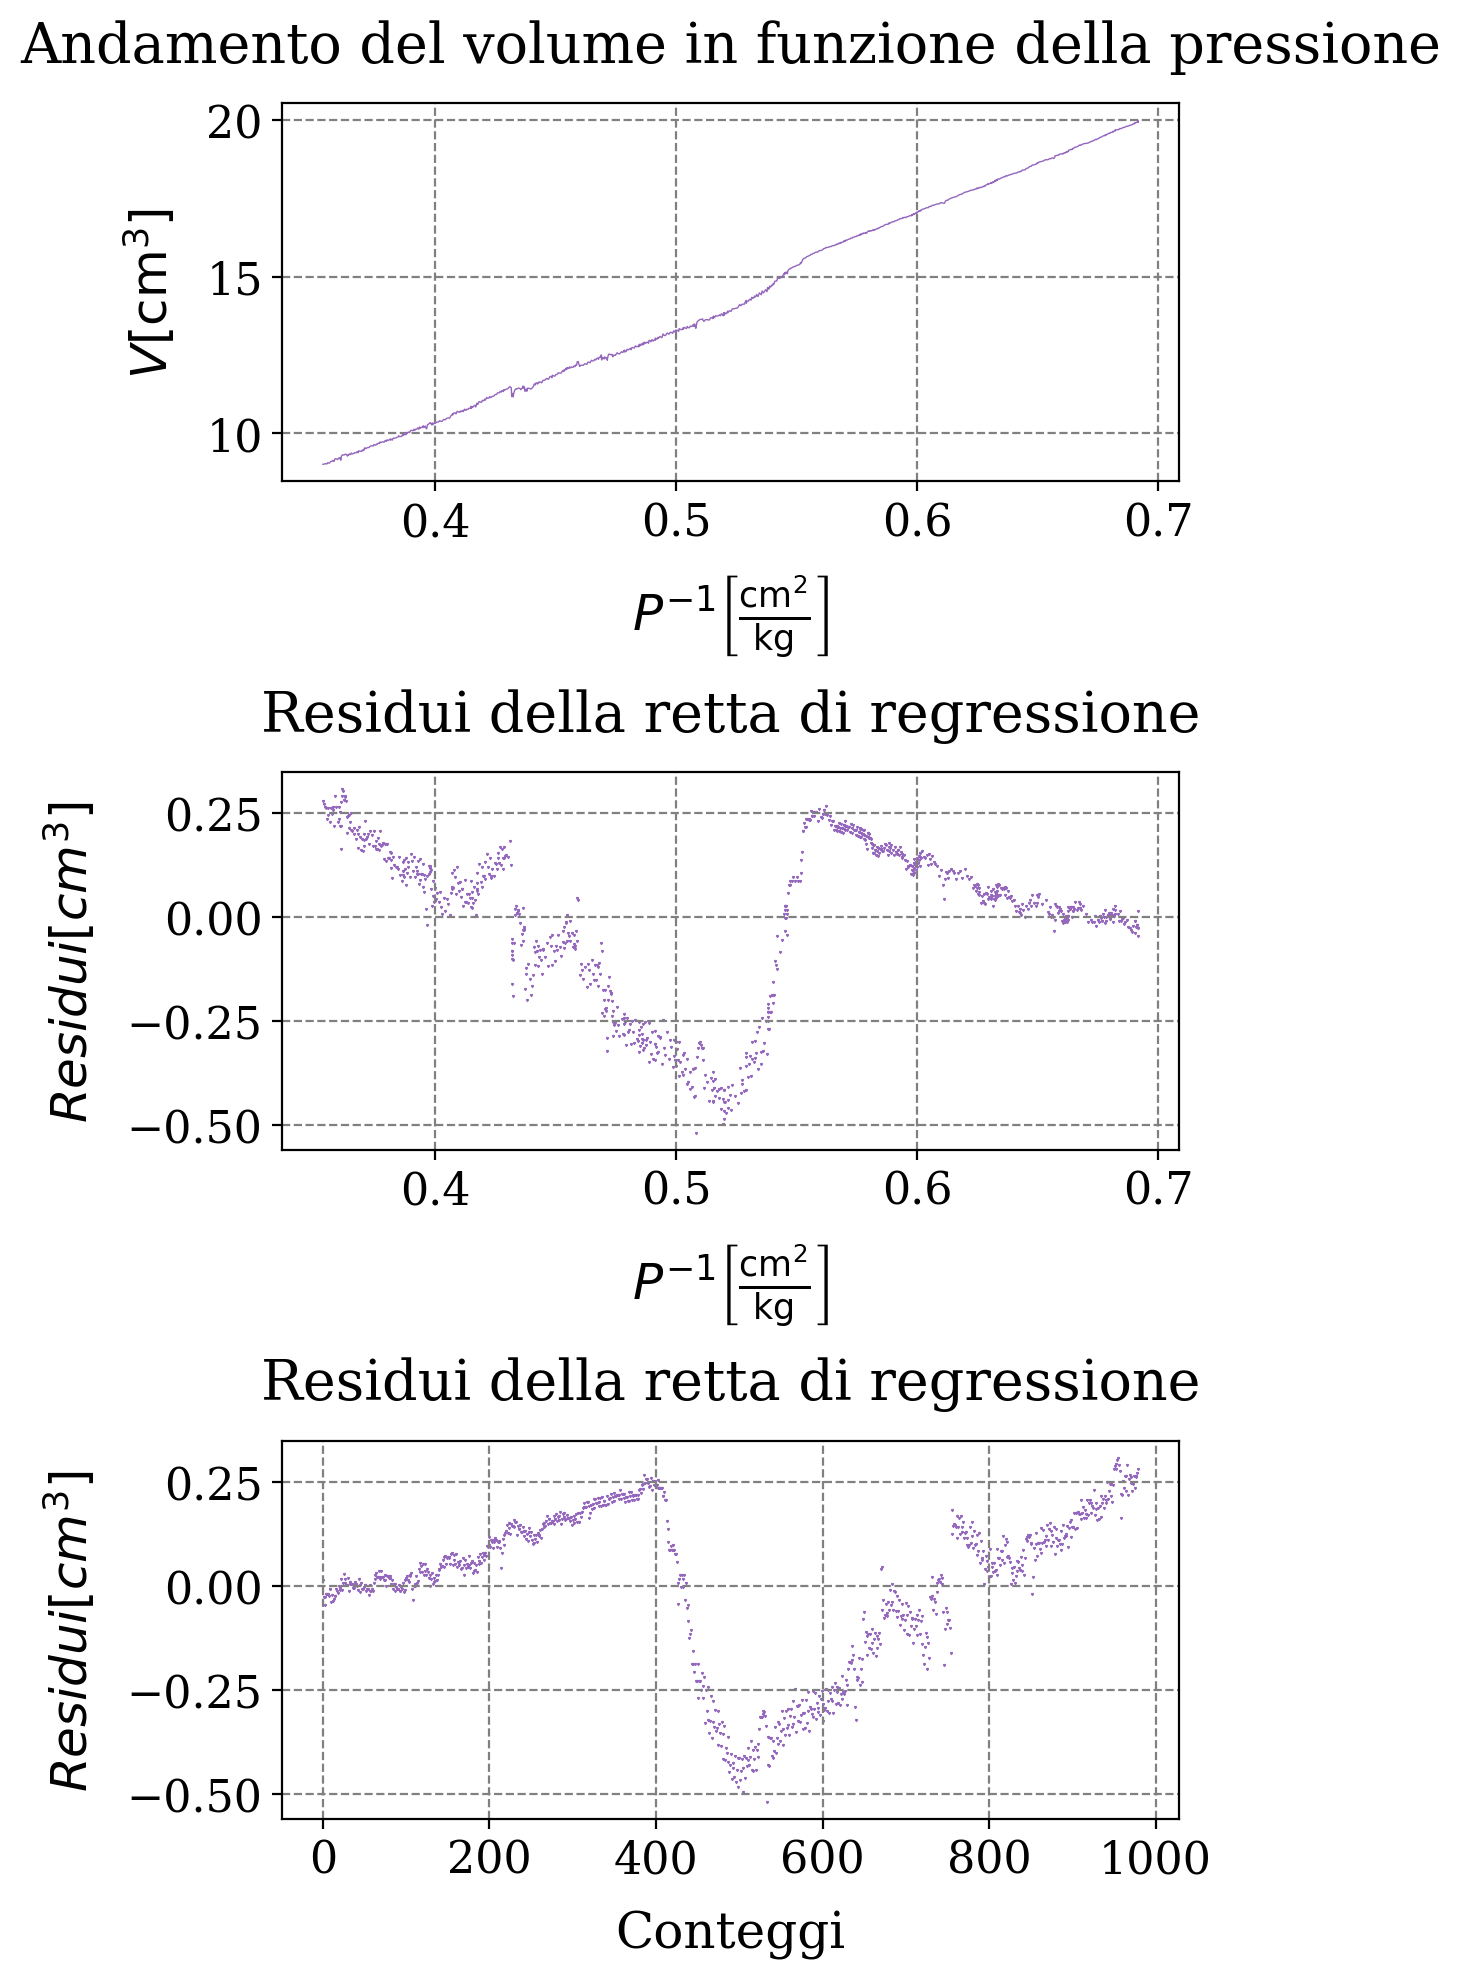

In [447]:
for temp,serie in dati.items():
    for fase_chiave, fase in serie.items():
        color = next(color_cycle)
        marker = next(marker_cycle)
        label = f"{temp} °C, {fase_chiave}"

        fig, axs = plt.subplots(3, 1, figsize=(6, 10))
        ax1 = axs[0]
        ax2 = axs[1]
        ax3 = axs[2]

        residui=[]
        a = parametri[temp][fase_chiave]["a"]
        b = parametri[temp][fase_chiave]["b"]

        for y,x in zip(fase["V"],fase["P"]):
            residui.append(y - (a + b * 1/x))
        residui = np.array(residui)
        indici = list(range(0, len(residui)))

        # Confronto
        ax1.plot(1 / fase["P"], fase["V"], linewidth=0.5, color=color)
        gf.parametri_grafico(ax1,
                             titolo = "Andamento del volume in funzione della pressione",
                             xlabel = r"$P^{-1} \left[\frac{\mathrm{cm}^2}{\mathrm{kg}}\right]$",
                             ylabel = r"$V [\mathrm{cm^{3}}]$")

        # Residui pressione
        ax2.scatter(1 / fase["P"], residui, marker=marker, s=0.3, linewidth=0.6, color=color)
        gf.parametri_grafico(ax2,
                             titolo = "Residui della retta di regressione",
                             xlabel = r"$P^{-1} \left[\frac{\mathrm{cm}^2}{\mathrm{kg}}\right]$",
                             ylabel = r"$Residui [cm^{3}]$")

        # Residui conteggi
        ax3.scatter(indici, residui, marker=marker, s=0.3, linewidth=0.6, color=color)
        gf.parametri_grafico(ax3,
                             titolo = "Residui della retta di regressione",
                             xlabel = "Conteggi",
                             ylabel = r"$Residui [cm^{3}]$")

        # Salva i grafici
        gf.salva_grafico(fig, f"./Images/Serie_{temp}_{fase_chiave}.pdf", noLegenda=True)